# Imports

In [2]:
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

In [60]:
# SPN Imports
from spn.structure.leaves.parametric.Parametric import Categorical
from spn.structure.Base import Product, Sum, assign_ids, rebuild_scopes_bottom_up, Leaf, get_nodes_by_type
from spn.algorithms.Inference import log_likelihood, likelihood
import spn.algorithms.Inference as spninf
from spn.io.Graphics import plot_spn

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
import itertools
import pandas as pd
import numpy as np
import time
from scipy import stats
from scipy.stats import skew, kurtosis

In [4]:
#Randomization
GLOBAL_SEED = 123
rng = np.random.default_rng(GLOBAL_SEED)

myseed = 123 #152

#The Evidence P(X6=0/1 | x2=1, x1=0, x7=0, x9=1)
evidence = np.full((1, 12), np.nan)
evidence[0, [1, 2, 7, 9]] = [0, 1, 0, 1]  # x1=0, x2=1, x7=0, x9=1

#Evidence for Variable Elimination
ve_evidence = {"X2":1, "X1":0, "X7":0, "X9":1}
samples = 2000 #Monte Carlo Sampling (Iterations)

# Data

# SPN

In [5]:
def build_spn(seed=None):
    global rng
    if seed is not None:
        rng = np.random.default_rng(seed)
    
    #Function to create a  boolean leaf node and p is probability that bollean value is 1
    def bool_leaf(i, p=0.5):
        return Categorical(p=[1-p, p], scope=i)
    
    #create leaf nodes
    leaves = [bool_leaf(i, p=0.3 + 0.02*i) for i in range(12)]
    
    #Layers of SPN
    
    #Layer 1 (Input layer)
    #Groups leaves into 2 to ensure decomposibility
    groups = []
    for i in range(0, 12, 2): #creates 12 leaf nodes (12 clues grouped into 6 pairs, meaning 6 teams of detectives looking at 2 clues each)
        g1 = Product(children=[leaves[i], leaves[i+1]]) # Simple clues
        g2 = Product(children=[bool_leaf(i, 0.6), bool_leaf(i+1, 0.4)]) #Complex clues
        groups.append((g1, g2))
        # product nodes mean AND. So we use them to consider all clues. This clue AND this clue
    
    #Layer 2
    # This is the supervisor now. Creates mixtures of probable clues from teams in g1 or g2
    mixtures = []
    for (g1, g2) in groups:
        w = rng.random(2)      # normalized weights. Supervisor trust is random between g1 and g2 (weights)
        w = w / w.sum()
        mixtures.append(Sum(children=[g1, g2], weights=w))
        # Sum nodes because sum means OR. So its g1 or g2
    
    #layer 3
    # Departmental head
    cluster_product = Product(children=mixtures)
    #Combines reports from 6 supervisors.
    # product because needs to combine all, so use AND
    
    
    #Layer 4
    #Final output
    w_top = rng.random(2)
    w_top = w_top / w_top.sum()
    top = Sum(children=[cluster_product, cluster_product], weights=w_top)
    
    
    
    assign_ids(top)
    rebuild_scopes_bottom_up(top) # build the SPN
    
    print("SPN built successfully!")
    all_nodes = get_nodes_by_type(top)
    print("Number of nodes:", len(all_nodes))
    print("Top weights:", w_top)
    print("\nMixture weights:")
    for i, m in enumerate(mixtures):
        print(f"  Mixture {i}: {m.weights}")
    return top    

In [6]:
spn = build_spn(seed=myseed)

SPN built successfully!
Number of nodes: 44
Top weights: [0.79406356 0.20593644]

Mixture weights:
  Mixture 0: [0.92689079 0.07310921]
  Mixture 1: [0.54445916 0.45554084]
  Mixture 2: [0.17804234 0.82195766]
  Mixture 3: [0.76950585 0.23049415]
  Mixture 4: [0.47948754 0.52051246]
  Mixture 5: [0.67680001 0.32319999]


Visualize SPN

INFO:spn.io.Graphics:[SumNode_0, ProductNode_1, SumNode_2, SumNode_3, SumNode_4, SumNode_5, SumNode_6, SumNode_7, ProductNode_8, ProductNode_9, ProductNode_10, ProductNode_11, ProductNode_12, ProductNode_13, ProductNode_14, ProductNode_15, ProductNode_16, ProductNode_17, ProductNode_18, ProductNode_19, CategoricalNode_20, CategoricalNode_21, CategoricalNode_22, CategoricalNode_23, CategoricalNode_24, CategoricalNode_25, CategoricalNode_26, CategoricalNode_27, CategoricalNode_28, CategoricalNode_29, CategoricalNode_30, CategoricalNode_31, CategoricalNode_32, CategoricalNode_33, CategoricalNode_34, CategoricalNode_35, CategoricalNode_36, CategoricalNode_37, CategoricalNode_38, CategoricalNode_39, CategoricalNode_40, CategoricalNode_41, CategoricalNode_42, CategoricalNode_43]


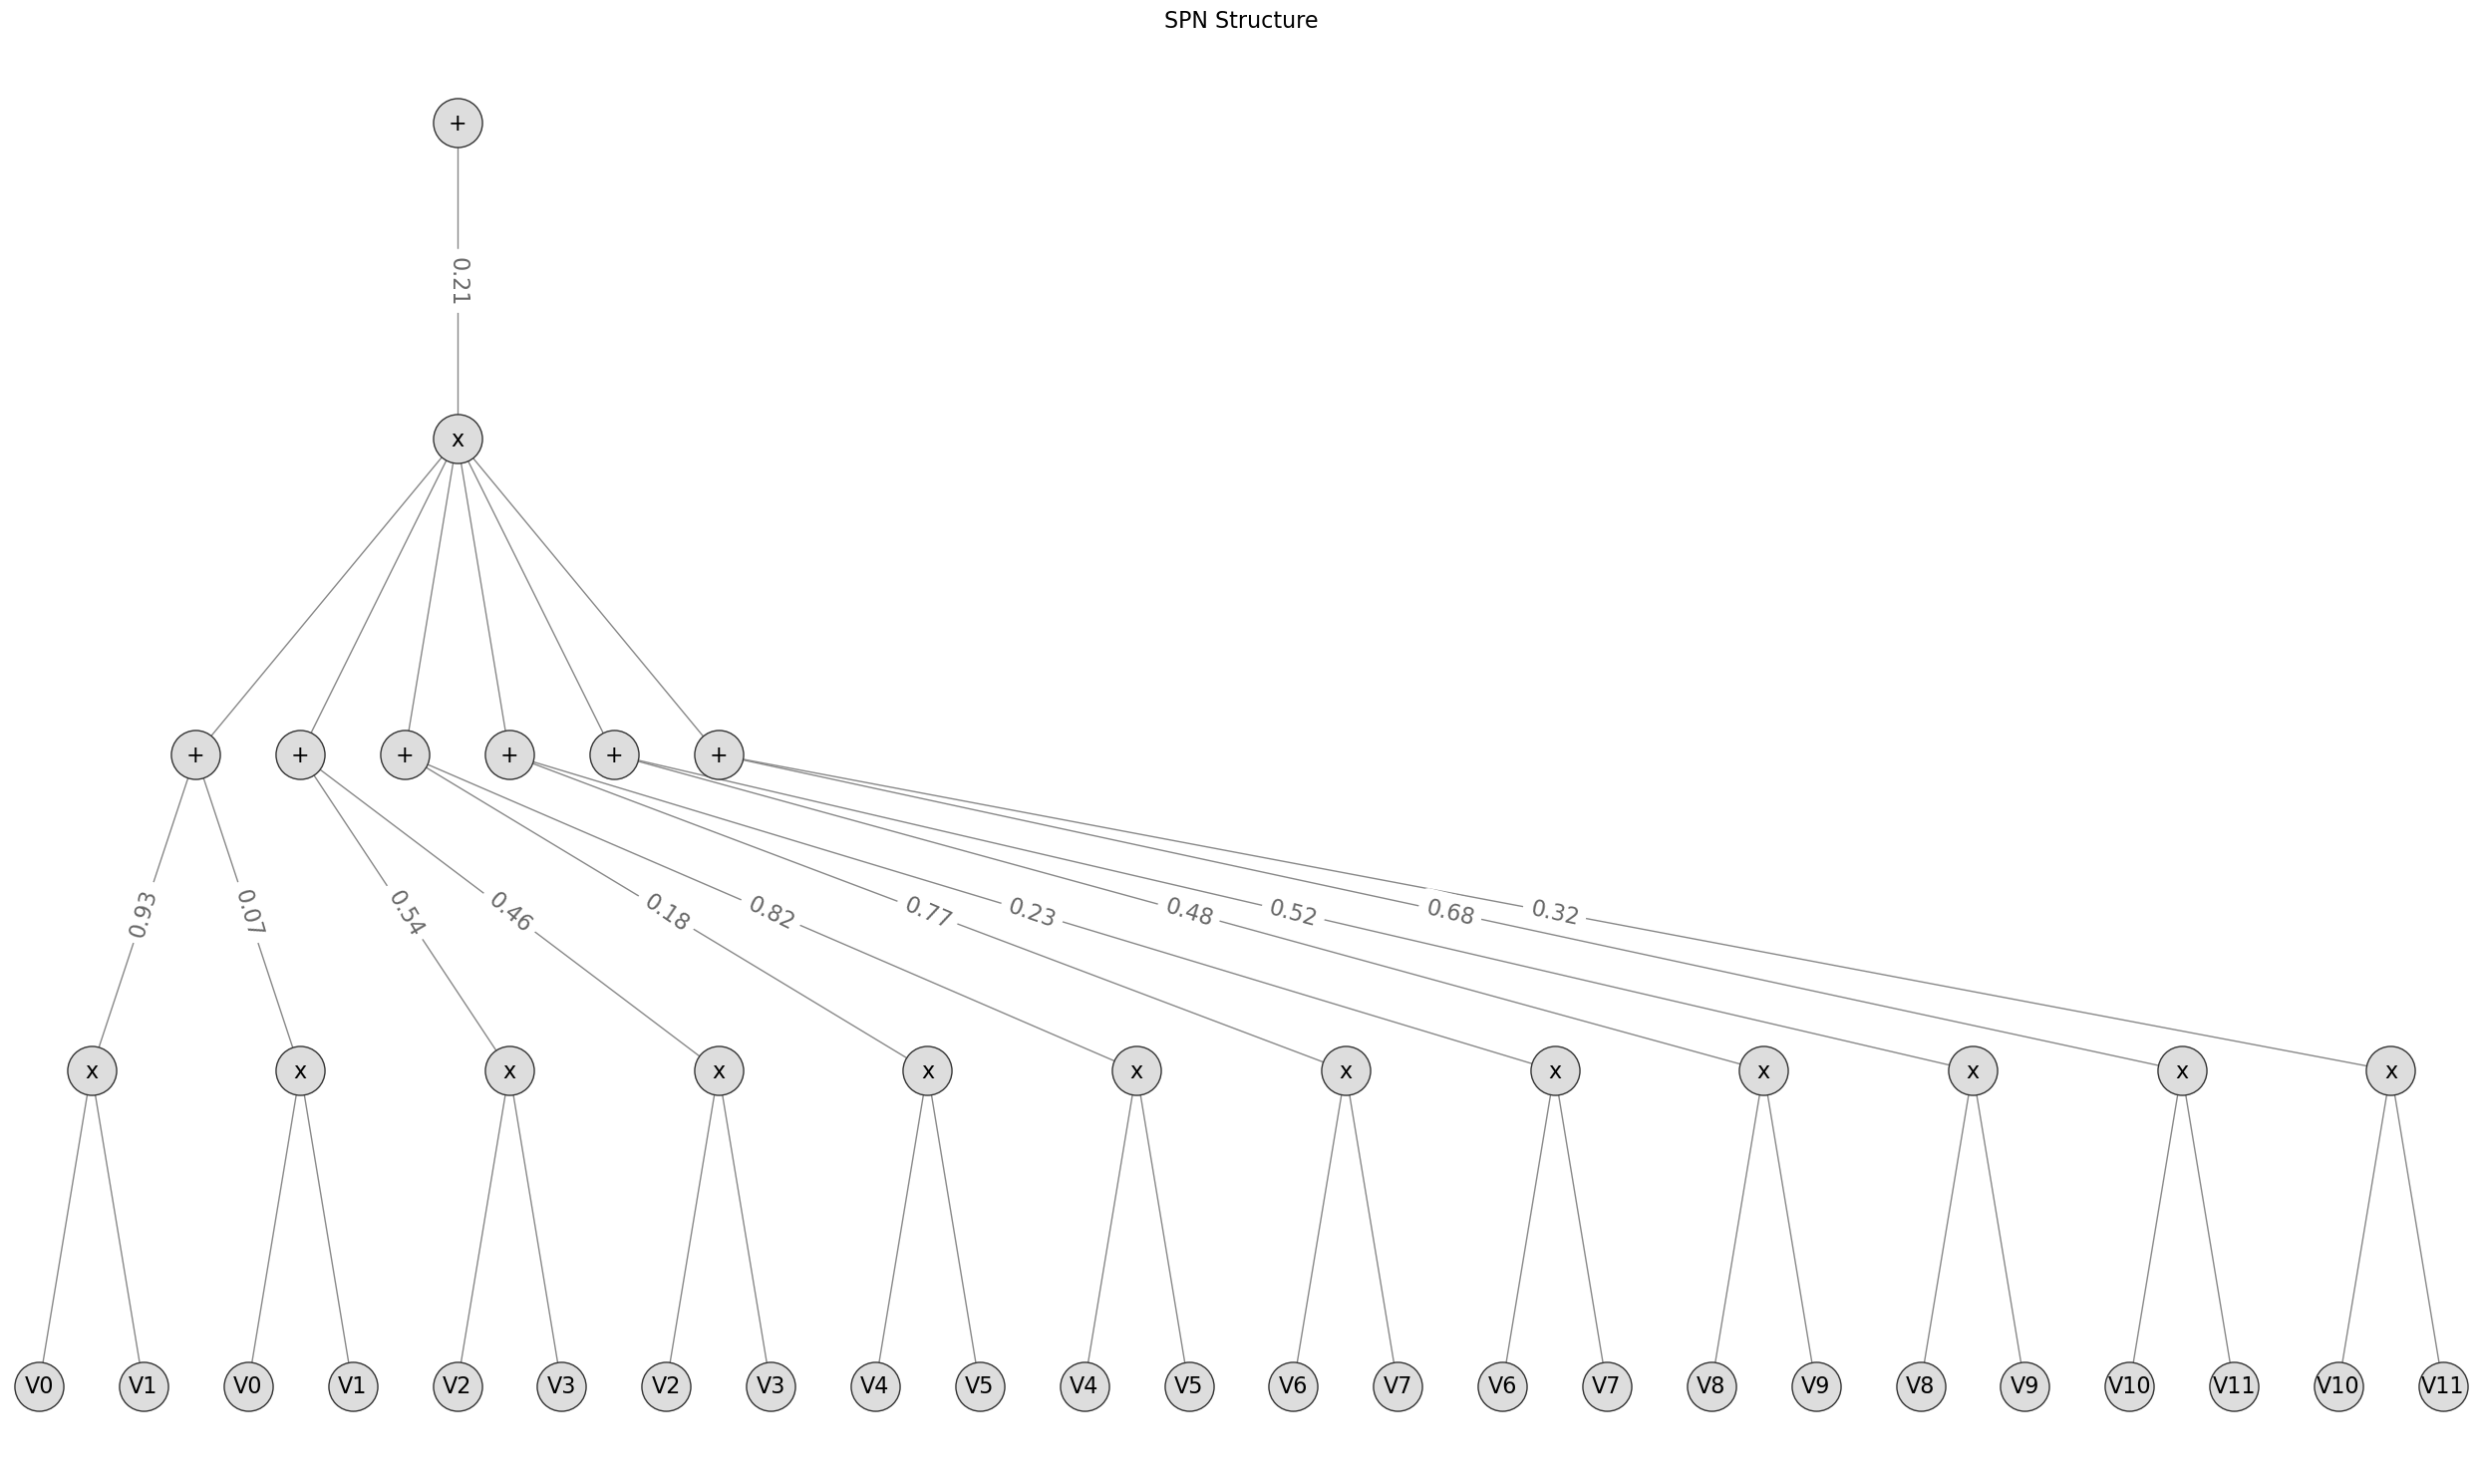

In [7]:
plt.figure(figsize=(25, 15))
plot_spn(spn)  # Remove feature_names parameter
plt.title('SPN Structure', fontsize=16)
plt.tight_layout()
plt.show()

Probabilities

In [8]:
#conditional probability
def conditional_probability(spn, evidence):
    # --------------------------
    # Denominator: P(Evidence)
    # --------------------------
    
    P_evidence = likelihood(spn, evidence)[0]

    # ----------------------------------------
    # Numerator for X6 = 0: P(X6=0, Evidence)
    # ----------------------------------------
    num0 = evidence.copy()
    num0[0, 6] = 0  # X6 = 0
    P_x6_0_evidence = likelihood(spn, num0)[0]

    # ----------------------------------------
    # Numerator for X6 = 1: P(X6=1, Evidence)
    # ----------------------------------------
    num1 = evidence.copy()
    num1[0, 6] = 1  # X6 = 1
    P_x6_1_evidence = likelihood(spn, num1)[0]

    # -------------------------
    # Final conditional values
    # -------------------------
    p0 = P_x6_0_evidence / P_evidence
    p1 = P_x6_1_evidence / P_evidence

    return p0, p1


# ---- CALL FUNCTION ----
p0_spn, p1_spn = conditional_probability(spn,evidence)

print("P(X6=0 | x2=1, x1=0, x7=0, x9=1) =", p0_spn)
print("P(X6=1 | x2=1, x1=0, x7=0, x9=1) =", p1_spn)
print("Sum =", p0_spn + p1_spn)

P(X6=0 | x2=1, x1=0, x7=0, x9=1) = [0.53626756]
P(X6=1 | x2=1, x1=0, x7=0, x9=1) = [0.46373244]
Sum = [1.]


# BN

In [9]:
sum_nodes = get_nodes_by_type(spn, Sum)

sum_nodes = sorted(sum_nodes, key=lambda s: s.id)
hidden_vars = [f"H{s.id}" for s in sum_nodes]
hidden_domains = [len(s.children) for s in sum_nodes]  # number of branches each H has

observable_vars = [f"X{i}" for i in range(12)]

def find_leaf_for_var(node, hidden_assign_map, var_index):
    if isinstance(node, Categorical):
        if var_index in node.scope:
            return node
        else:
            return None

    if isinstance(node, Sum):
        Hname = f"H{node.id}"
        chosen = hidden_assign_map[Hname]
        chosen_child = node.children[chosen]
        return find_leaf_for_var(chosen_child, hidden_assign_map, var_index)

    if isinstance(node, Product):
        for ch in node.children:
            if var_index in ch.scope:
                return find_leaf_for_var(ch, hidden_assign_map, var_index)
        return None
    return None

all_hidden_assignments = list(itertools.product(*[range(d) for d in hidden_domains]))
hidden_assignment_maps = []
for tup in all_hidden_assignments:
    m = {hidden_vars[i]: int(tup[i]) for i in range(len(hidden_vars))}
    hidden_assignment_maps.append(m)

cpts = {} 
all_hidden_assignments = list(itertools.product(*[range(d) for d in hidden_domains]))
for xi in range(12):
    shape = tuple(hidden_domains) + (2,)
    table = np.zeros(shape, dtype=float)
    for tup in all_hidden_assignments:
        multi_idx = tuple(int(v) for v in tup)
        hmap = {hidden_vars[i]: int(tup[i]) for i in range(len(hidden_vars))}
        leaf = find_leaf_for_var(spn, hmap, xi)
        if leaf is None:
            raise RuntimeError(f"No leaf found for X{xi} under assignment {hmap}")
        pvec = getattr(leaf, "p", None)
        if pvec is None:
            pvec = getattr(leaf, "probs", None)
        if pvec is None:
            raise RuntimeError("Cannot read probability vector from leaf; check Categorical implementation.")
        table[multi_idx + (0,)] = float(pvec[0])  
        table[multi_idx + (1,)] = float(pvec[1])  
    cpts[f"X{xi}"] = table

hidden_priors = {}
for i, s in enumerate(sum_nodes):
    H = hidden_vars[i]
    w = getattr(s, "weights", None)
    if w is None:
        w = getattr(s, "w", None)
    if w is None:
        raise RuntimeError("Cannot find sum-node weights on sum node id=%s" % s.id)
    w = np.array(w, dtype=float)
    if w.sum() == 0:
        raise RuntimeError("Sum-node weights sum to zero")
    w = w / w.sum()
    hidden_priors[H] = w.copy()

def domain_size(var):
    if var.startswith("H"):
        return hidden_domains[hidden_vars.index(var)]
    if var.startswith("X"):
        return 2
    raise RuntimeError("Unknown var domain for " + var)

def make_factor(vars_list, table):
    return {"vars": list(vars_list), "table": np.array(table, dtype=float)}

factors = []

for H in hidden_vars:
    w = hidden_priors[H]
    factors.append(make_factor([H], w.copy()))

for X in observable_vars:
    factors.append(make_factor(hidden_vars + [X], cpts[X].copy()))

def multiply_factors(f1, f2):
    vars1, vars2 = f1["vars"], f2["vars"]

    new_vars = list(vars1) + [v for v in vars2 if v not in vars1]

    def reshape_table(f, target_vars):
        old_vars  = f["vars"]
        old_table = f["table"]

        perm = []
        for v in target_vars:
            if v in old_vars:
                perm.append(old_vars.index(v))
            else:
                perm.append(None)

        existing_axes = [p for p in perm if p is not None]
        reordered = old_table
        if existing_axes != list(range(len(old_vars))):
            reordered = np.transpose(old_table, existing_axes)

        new_shape = [
            domain_size(v) if v in old_vars else 1
            for v in target_vars
        ]
        return reordered.reshape(new_shape)

    A = reshape_table(f1, new_vars)
    B = reshape_table(f2, new_vars)

    prod = A * B
    return make_factor(new_vars, prod)

def sum_out_factor(f, var):
    if var not in f["vars"]:
        return f 
    idx = f["vars"].index(var)
    new_vars = f["vars"][:idx] + f["vars"][idx+1:]
    new_table = f["table"].sum(axis=idx)
    return make_factor(new_vars, new_table)

def restrict_factor(f, evidence):
    vars_in = list(f["vars"])
    table = f["table"]
    for var, val in evidence.items():
        if var in vars_in:
            idx = vars_in.index(var)
            table = np.take(table, indices=int(val), axis=idx)
            vars_in.pop(idx)
    return make_factor(vars_in, table)

# Variable Elimination 

In [10]:
# Variable Elimination routine
def variable_elimination(factors, query_var, evidence):
    facs = [restrict_factor(f, evidence) for f in factors]
    all_vars = set()
    for f in facs:
        all_vars.update(f["vars"])
    elim_vars = [v for v in all_vars if v != query_var and v not in evidence]

    for Z in elim_vars:
        bucket = [f for f in facs if Z in f["vars"]]
        if not bucket:
            continue
        facs = [f for f in facs if Z not in f["vars"]]
        phi = bucket[0]
        for f in bucket[1:]:
            phi = multiply_factors(phi, f)
        phi = sum_out_factor(phi, Z)
        facs.append(phi)

    result = facs[0]
    for f in facs[1:]:
        result = multiply_factors(result, f)

    for v in list(result["vars"]):
        if v != query_var:
            result = sum_out_factor(result, v)

    vals = result["table"]
    total = vals.sum()
    if total == 0:
        norm = np.ones_like(vals) / vals.size
    else:
        norm = vals / total
    return norm

VE Inference

In [11]:
query = "X6"
post_ve = variable_elimination(factors, query, ve_evidence)

print("VE result P(X6=0 | E) =", float(post_ve[0]))
print("VE result P(X6=1 | E) =", float(post_ve[1]))
print("Sum =", float(post_ve.sum()))

VE result P(X6=0 | E) = 0.5362675623989441
VE result P(X6=1 | E) = 0.4637324376010558
Sum = 1.0


Analytics

In [12]:
def total_variation_distance(p, q):
    """
    p, q: 1D numpy arrays representing probability distributions
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return 0.5 * np.sum(np.abs(p - q))

# VE posterior (ground truth)
#post_ve = post  # shape (2,)

# SPN posterior
#p0_spn, p1_spn = conditional_probability(spn)
post_spn = np.array([float(p0_spn), float(p1_spn)])

tv = total_variation_distance(post_ve, post_spn)

print("Total Variation Distance (SPN vs VE):", tv)


Total Variation Distance (SPN vs VE): 1.1102230246251565e-16


C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\694507717.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  post_spn = np.array([float(p0_spn), float(p1_spn)])


In [13]:
def kl_divergence(p, q, eps=1e-12):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))

kl = kl_divergence(post_ve, post_spn)
print("KL(VE || SPN):", kl)


KL(VE || SPN): -2.2204460492503136e-16


Plot Analytics

C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\3507399885.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_spn = np.array([float(p0_spn), float(p1_spn)])


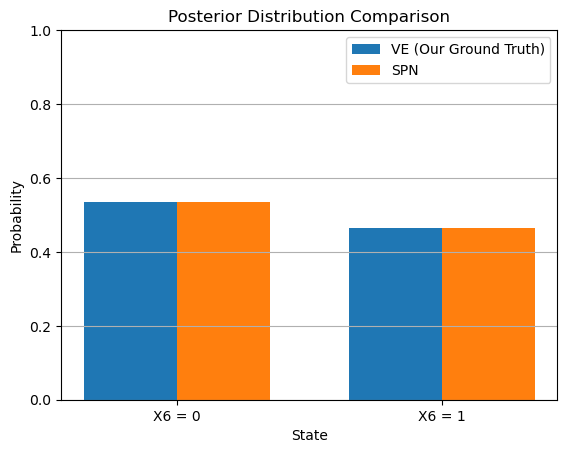

In [14]:
def plot_posterior_comparison(p_ve, p_spn):
    """
    p_ve  : array-like, e.g. [P(X=0), P(X=1)]
    p_spn : array-like, same ordering
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure()

    plt.bar(x - width/2, p_ve, width, label="VE (Our Ground Truth)")
    plt.bar(x + width/2, p_spn, width, label="SPN")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y")

    plt.show()

# VE posterior
p_ve = np.array([post_ve[0], post_ve[1]])

# SPN posterior
p_spn = np.array([float(p0_spn), float(p1_spn)])

plot_posterior_comparison(p_ve, p_spn)

# SPN with MCD

MCD

In [15]:
def mcd(spn, X, dropout_rate=0.2, samples=50):
    # Collect all sum nodes once
    sum_nodes = get_nodes_by_type(spn, Sum)

    results = []

    for _ in range(samples):
        dropped = {}
        for s in sum_nodes:
            mask = np.random.rand(len(s.children)) > dropout_rate
            if not np.any(mask):         # avoid dropping all
                mask[np.random.randint(0, len(mask))] = True
            dropped[s] = mask

        backup_weights = {}
        for s, mask in dropped.items():
            backup_weights[s] = s.weights.copy()
            new_w = s.weights * mask
            s.weights = new_w / new_w.sum()

        val = likelihood(spn, X)[0]
        results.append(val)

        for s, old in backup_weights.items():
            s.weights = old

    results = np.array(results)

    return results.mean(), results.var(), results


In [16]:
mcd_mean, mcd_var, mcd_samples = mcd(spn, evidence, dropout_rate = 0.2,samples=samples)
print("MC Dropout Likelihood Mean:", mcd_mean)
print("Predictive Uncertainty Var:", mcd_var)


MC Dropout Likelihood Mean: 0.0772606161320381
Predictive Uncertainty Var: 0.0002016978287653578


In [17]:
def mcd_conditional(spn, query_index, evidence, dropout_rate=0.2, samples=50):
    sum_nodes = get_nodes_by_type(spn, Sum)
    p1_samples = []

    for _ in range(samples):
        dropped = {}
        for s in sum_nodes:
            mask = np.random.rand(len(s.children)) > dropout_rate
            if not np.any(mask):
                mask[np.random.randint(len(mask))] = True
            dropped[s] = mask

        backups = {}
        for s, mask in dropped.items():
            backups[s] = s.weights.copy()
            w = s.weights * mask
            s.weights = w / w.sum()

        e0 = evidence.copy()
        e1 = evidence.copy()
        e0[0, query_index] = 0
        e1[0, query_index] = 1

        p0 = likelihood(spn, e0)[0]
        p1 = likelihood(spn, e1)[0]
        Z = p0 + p1 + 1e-12
        p1_samples.append(p1 / Z)

        for s, w_old in backups.items():
            s.weights = w_old

    p1_samples = np.array(p1_samples)
    return p1_samples.mean(), p1_samples.var(), p1_samples

mcdc_mean, mcdc_var, mcdc_samples = mcd_conditional(spn, query_index=6, evidence=evidence, dropout_rate=0.2, samples=samples)
print("MC Dropout Likelihood Mean:", mcdc_mean)
print("Predictive Uncertainty Var:", mcdc_var)

MC Dropout Likelihood Mean: 0.48059062627707605
Predictive Uncertainty Var: 0.003418148972611207


Conditional Probability

In [18]:
def mc_dropout_likelihood(spn, X, dropout_rate=0.2, samples=50):
    sum_nodes = get_nodes_by_type(spn, Sum)

    results = []

    for _ in range(samples):
        dropped = {}
        for s in sum_nodes:
            mask = np.random.rand(len(s.children)) > dropout_rate
            if not np.any(mask):         # avoid dropping all
                mask[np.random.randint(0, len(mask))] = True
            dropped[s] = mask
        
        backup_weights = {}
        for s, mask in dropped.items():
            backup_weights[s] = s.weights.copy()
            new_w = s.weights * mask
            s.weights = new_w / new_w.sum()

        val = likelihood(spn, X)[0]
        results.append(val)

        for s, old in backup_weights.items():
            s.weights = old

    results = np.array(results)

    return results.mean(), results.var(), results

In [19]:
def mc_dropout_conditional(spn, query_index, evidence, **kw):
    e0 = evidence.copy()
    e1 = evidence.copy()
    e0[0, query_index] = 0
    e1[0, query_index] = 1

    m0, _, _ = mc_dropout_likelihood(spn, e0, **kw)
    m1, _, _ = mc_dropout_likelihood(spn, e1, **kw)

    Z = m0 + m1
    return m0/Z, m1/Z

p0_mcd,p1_mcd = mc_dropout_conditional(spn, 6, evidence, dropout_rate=0.2, samples=samples)
print("P(X6=0 | E) =", p0_mcd, "± uncertainty")
print("P(X6=1 | E) =", p1_mcd, "± uncertainty")

P(X6=0 | E) = 0.5171547679970925 ± uncertainty
P(X6=1 | E) = 0.4828452320029077 ± uncertainty


In [20]:
ve_array = np.full_like(mcdc_samples, post_ve[1])

t_stat, p_value = stats.ttest_rel(mcdc_samples, ve_array)

print("Paired t-test vs VE")
print("t-statistic:", t_stat)
print("p-value:", p_value)

Paired t-test vs VE
t-statistic: [12.89204503]
p-value: [1.37241568e-36]


Visual Analytics

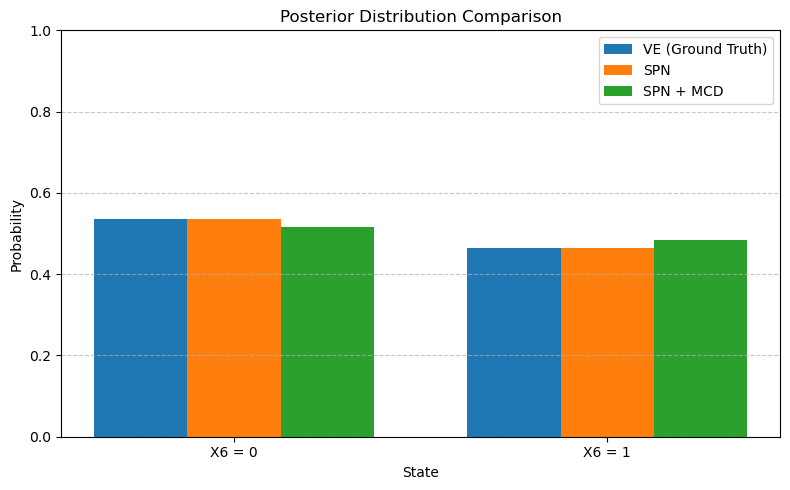

In [21]:
def plot_posterior_comparison_with_mcd(p_ve, p_spn, p_mcd):
    """
    p_ve  : [P(X=0), P(X=1)] from Variable Elimination
    p_spn : deterministic SPN posterior
    p_mcd : Monte Carlo Dropout posterior mean
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(8, 5))

    plt.bar(x - width, p_ve, width, label="VE (Ground Truth)")
    plt.bar(x,         p_spn, width, label="SPN")
    plt.bar(x + width, p_mcd, width, label="SPN + MCD")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

p_mcd = np.array([float(p0_mcd), float(p1_mcd)])    
plot_posterior_comparison_with_mcd(p_ve, p_spn, p_mcd)

In [22]:
def mc_dropout_conditional_samples(spn, query_index, evidence,
                                   dropout_rate=0.2, samples=2000):

    p_samples = []

    for _ in range(samples):
        e0 = evidence.copy()
        e1 = evidence.copy()
        e0[0, query_index] = 0
        e1[0, query_index] = 1

        m0, _, _ = mc_dropout_likelihood(
            spn, e0, dropout_rate=dropout_rate, samples=1
        )
        m1, _, _ = mc_dropout_likelihood(
            spn, e1, dropout_rate=dropout_rate, samples=1
        )

        Z = m0 + m1
        p_samples.append([m0 / Z, m1 / Z])

    return np.array(p_samples)

p_mcd_samples = mc_dropout_conditional_samples(
    spn, 6, evidence, dropout_rate=0.2, samples=samples
)

def tvd(p, q):
    return 0.5 * np.sum(np.abs(p - q))

def kl(p, q):
    eps = 1e-12
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))

tvd_vals = np.array([tvd(p_ve, p) for p in p_mcd_samples])
kl_vals  = np.array([kl(p_ve, p)  for p in p_mcd_samples])

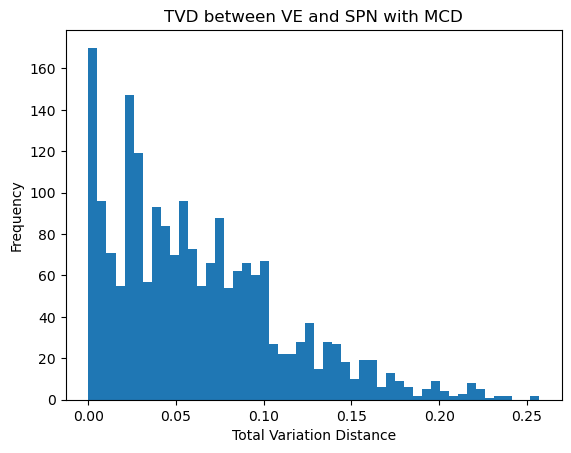

In [23]:
plt.figure()
plt.hist(tvd_vals, bins=50)
plt.xlabel("Total Variation Distance")
plt.ylabel("Frequency")
plt.title("TVD between VE and SPN with MCD")
plt.show()


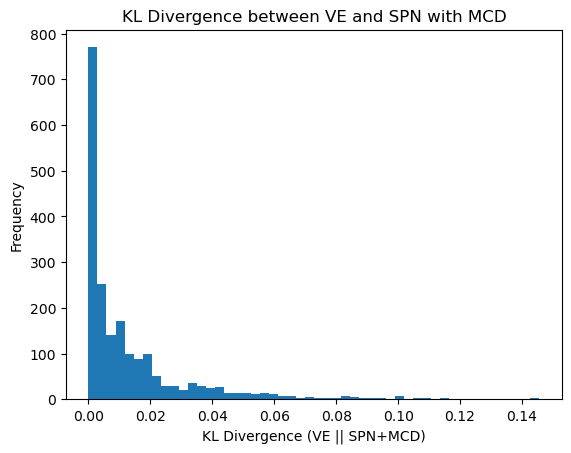

In [24]:
plt.figure()
plt.hist(kl_vals, bins=50)
plt.xlabel("KL Divergence (VE || SPN+MCD)")
plt.ylabel("Frequency")
plt.title("KL Divergence between VE and SPN with MCD")
plt.show()


# SPN + Bayesian Improvements

Creating the SPN with Bayesian Leaves First

In [25]:
# The Bayesian Leaves Structure
class BayesianCategoricalLeaf(Leaf):
    def __init__(self, scope, alpha):
        """
        alpha: Dirichlet prior parameters [alpha_0, alpha_1]
        """
        super().__init__(scope=scope)
        self.alpha = np.asarray(alpha, dtype=float)
        self.alpha_sum = np.sum(self.alpha)

    def marginal_prob(self, value):
        """
        Closed-form marginal likelihood:
        E[theta_k] = alpha_k / sum(alpha)
        """
        return self.alpha[value] / self.alpha_sum


#Now we moce to evaluation functions for the leaves
#Probability Space Evaluation
def bayesian_cat_eval(node, data=None, **kwargs):
    col = int(node.scope[0])

    if data is None:
        raise ValueError("Data is None")

    arr = np.asarray(data)
    out = np.ones((arr.shape[0], 1))

    for i in range(arr.shape[0]):
        x = arr[i, col]

        if np.isnan(x):
            out[i, 0] = 1.0  # marginalize missing evidence
        else:
            out[i, 0] = node.marginal_prob(int(x))

    return out
    
#Log Space Evaluation
def bayesian_cat_log_eval(node, data=None, **kwargs):
    val = bayesian_cat_eval(node, data=data)
    return np.log(np.clip(val, 1e-12, None))

#Resgister the behaviour of the leaves
BayesianCategoricalLeaf._is_leaf = True
BayesianCategoricalLeaf._eval_func = [bayesian_cat_eval]
BayesianCategoricalLeaf._log_eval_func = [bayesian_cat_log_eval]

#The Leaf 
def bayesian_bool_leaf(i, p=0.5, strength=10.0):
    """
    p        : prior mean
    strength : confidence (higher = less uncertainty)
    """
    alpha = [
        (1 - p) * strength,
        p * strength
    ]
    return BayesianCategoricalLeaf(scope=i, alpha=alpha)


#The SPN that uses the new leaf
def build_bayesian_spn(seed=None):
    global rng
    if seed is not None:
        rng = np.random.default_rng(seed)

    # Create Bayesian leaf nodes
    leaves = [
        bayesian_bool_leaf(i, p=0.3 + 0.02 * i, strength=10.0)
        for i in range(12)
    ]

    # Layer 1: products
    groups = []
    for i in range(0, 12, 2):
        g1 = Product(children=[leaves[i], leaves[i+1]])

        g2 = Product(children=[
            bayesian_bool_leaf(i, p=0.6, strength=10.0),
            bayesian_bool_leaf(i+1, p=0.4, strength=10.0)
        ])

        groups.append((g1, g2))

    # Layer 2: mixtures
    mixtures = []
    for g1, g2 in groups:
        w = rng.random(2)
        w /= w.sum()
        mixtures.append(Sum(children=[g1, g2], weights=w))

    # Layer 3: product
    cluster_product = Product(children=mixtures)

    # Layer 4: top sum
    w_top = rng.random(2)
    w_top /= w_top.sum()
    top = Sum(children=[cluster_product, cluster_product], weights=w_top)

    assign_ids(top)
    rebuild_scopes_bottom_up(top)

    print("Number of nodes:", len(get_nodes_by_type(top)))

    return top


In [26]:
bayespn = build_bayesian_spn(seed=myseed)

Number of nodes: 44


In [27]:
def temp_scaling(spn, temperature):
    """
    Apply temperature scaling to all Sum nodes.
    Stores original weights for later restoration.
    """
    sum_nodes = get_nodes_by_type(spn, Sum)
    backups = {}

    for s in sum_nodes:
        backups[s] = s.weights.copy()
        w = s.weights
        w_scaled = np.power(w, temperature)
        w_scaled = w_scaled / np.sum(w_scaled)
        s.weights = w_scaled
    return backups

def restore_weights(backups):
    """Restore original Sum-node weights."""
    for s, w in backups.items():
        s.weights = w

def temperature_scaled_likelihood(spn, X, temperature):
    """
    Deterministic uncertainty control via temperature-scaled mixture weights.
    """
    backups = temp_scaling(spn, temperature)
    val = likelihood(spn, X)[0]
    restore_weights(backups)
    return val

def temperature_scaled_conditional_probability(spn, query_index, evidence, temperature):
    e0 = evidence.copy()
    e1 = evidence.copy()

    e0[0, query_index] = 0
    e1[0, query_index] = 1

    p0 = temperature_scaled_likelihood(spn, e0, temperature)
    p1 = temperature_scaled_likelihood(spn, e1, temperature)

    Z = p0 + p1
    return p0 / Z, p1 / Z

def temperature_sweep(spn, query_index, evidence, temperatures):
    p0_vals, p1_vals = [], []

    for tau in temperatures:
        p0, p1 = temperature_scaled_conditional_probability(
            spn, query_index, evidence, tau
        )
        p0_vals.append(p0)
        p1_vals.append(p1)

    return np.array(p0_vals), np.array(p1_vals)

# Single temperature
p0_temp, p1_temp = temperature_scaled_conditional_probability(
    bayespn, query_index=6, evidence=evidence, temperature=1.1
)
p_temp = np.array([float(p0_temp), float(p1_temp)])

print("Temperature-scaled posterior:")
print("P(X6=0 | E) =", p0_temp)
print("P(X6=1 | E) =", p1_temp)

# Sweep
taus = np.linspace(0.5, 2.5, 20)
p0_vals, _ = temperature_sweep(spn, 6, evidence, taus)

print("Posterior variance across temperatures:", np.var(p0_vals))


Temperature-scaled posterior:
P(X6=0 | E) = [0.54013422]
P(X6=1 | E) = [0.45986578]
Posterior variance across temperatures: 0.00031043577401780674


C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\614087922.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_temp = np.array([float(p0_temp), float(p1_temp)])


In [28]:
def temperature_marginalized_conditional(spn, query_index, evidence, T_mean=1.5, T_std=0.3, samples=500):
    sum_nodes = get_nodes_by_type(spn, Sum)

    p1_samples = []

    for _ in range(samples):
        # Sample temperature
        T = np.random.lognormal(
            mean=np.log(T_mean),
            sigma=T_std
        )

        backups = {}
        for s in sum_nodes:
            backups[s] = s.weights.copy()
            w = s.weights ** (1.0 / T)
            s.weights = w / w.sum()

        # Conditional probability
        e0 = evidence.copy()
        e1 = evidence.copy()
        e0[0, query_index] = 0
        e1[0, query_index] = 1

        p0 = likelihood(spn, e0)[0]
        p1 = likelihood(spn, e1)[0]
        Z = p0 + p1 + 1e-12
        p1_samples.append(p1 / Z)

        # Restore weights
        for s, w_old in backups.items():
            s.weights = w_old

    p1_samples = np.array(p1_samples)

    return {
        "mean": p1_samples.mean(),
        "var": p1_samples.var(),
        "samples": p1_samples
    }
temp_results = temperature_marginalized_conditional(spn=bayespn, query_index=6, evidence=evidence, T_mean=1.1, T_std=0.3, samples=samples)

p1_temp_mean = temp_results["mean"]
p1_temp_var  = temp_results["var"]
p1_temp_samples = temp_results["samples"]

p0_temp_mean = 1.0 - p1_temp_mean

p_temp_marg = np.array([
    1.0 - p1_temp_mean,
    p1_temp_mean
])


print("SPN + Bayesian Temperature Scaling")
print(f"P(X6=0 | E) = {p0_temp_mean:.4f}")
print(f"P(X6=1 | E) = {p1_temp_mean:.4f}")
print(f"Predictive variance = {p1_temp_var:.6f}")


SPN + Bayesian Temperature Scaling
P(X6=0 | E) = 0.5328
P(X6=1 | E) = 0.4672
Predictive variance = 0.000123


In [29]:
upgrade_results = temperature_marginalized_conditional(spn=spn, query_index=6, evidence=evidence, T_mean=1.1, T_std=0.3, samples=samples)

p1_upgrade_mean = upgrade_results["mean"]
p1_upgrade_var  = upgrade_results["var"]
p1_upgrade_samples = upgrade_results["samples"]

p0_upgrade_mean = 1.0 - p1_upgrade_mean

upgrade_marg = np.array([
    1.0 - p1_upgrade_mean,
    p1_upgrade_mean
])


print("SPN + Bayesian Temperature Scaling")
print(f"P(X6=0 | E) = {p0_upgrade_mean:.4f}")
print(f"P(X6=1 | E) = {p1_upgrade_mean:.4f}")
print(f"Predictive variance = {p1_upgrade_var:.6f}")

SPN + Bayesian Temperature Scaling
P(X6=0 | E) = 0.5333
P(X6=1 | E) = 0.4667
Predictive variance = 0.000119


# Statistical Analysis

Descriptive Statistics

In [61]:
samples_mcd = np.array(mcdc_samples)
samples_upgrade = np.array(p1_upgrade_samples)
samples_temp = np.array(p1_temp_samples)

def descriptive_stats(samples):
    stats = {
        "count": len(samples),
        "mean": np.mean(samples),
        "median": np.median(samples),
        "min": np.min(samples),
        "max": np.max(samples),
        "range": np.max(samples) - np.min(samples),
        "Q1": np.percentile(samples, 25),
        "Q3": np.percentile(samples, 75),
        "IQR": np.percentile(samples, 75) - np.percentile(samples, 25),
        "skewness": skew(samples),
        "kurtosis": kurtosis(samples)
    }
    return stats

# Compute statistics for each inference method
stats_mcd = descriptive_stats(samples_mcd)
stats_upgrade = descriptive_stats(samples_upgrade)
stats_temp = descriptive_stats(samples_temp)

In [62]:
stats_mcd

{'count': 2000,
 'mean': np.float64(0.48059062627707605),
 'median': np.float64(0.46373243759504246),
 'min': np.float64(0.4199999999908088),
 'max': np.float64(0.5999999999948937),
 'range': np.float64(0.18000000000408495),
 'Q1': np.float64(0.46373243759294763),
 'Q3': np.float64(0.4637324375964611),
 'IQR': np.float64(3.5134672948800016e-12),
 'skewness': array([1.32803969]),
 'kurtosis': array([0.35990088])}

In [63]:
stats_upgrade

{'count': 2000,
 'mean': np.float64(0.4667378828485454),
 'median': np.float64(0.4675874164358085),
 'min': np.float64(0.43010364401092144),
 'max': np.float64(0.4968725783766401),
 'range': np.float64(0.06676893436571868),
 'Q1': np.float64(0.45941923697870307),
 'Q3': np.float64(0.4747138304311718),
 'IQR': np.float64(0.015294593452468752),
 'skewness': array([-0.25078925]),
 'kurtosis': array([-0.20749013])}

In [64]:
stats_temp

{'count': 2000,
 'mean': np.float64(0.46715155982936823),
 'median': np.float64(0.46824634442269564),
 'min': np.float64(0.4314652497024637),
 'max': np.float64(0.49722596526490037),
 'range': np.float64(0.06576071556243668),
 'Q1': np.float64(0.4602469766604913),
 'Q3': np.float64(0.4750122839073079),
 'IQR': np.float64(0.014765307246816572),
 'skewness': array([-0.41073405]),
 'kurtosis': array([-0.05617413])}

In [30]:
# MCD vs Temp-SPN
t1, p1 = stats.ttest_rel(mcdc_samples, p1_upgrade_samples)

# Temp-SPN vs BayesTemp-SPN
t2, p2 = stats.ttest_rel(p1_upgrade_samples, p1_temp_samples)

# MCD vs BayesTemp-SPN
t3, p3 = stats.ttest_rel(mcdc_samples, p1_temp_samples)

print("MCD vs Temp-SPN:", t1, p1)
print("Temp-SPN vs BayesTemp-SPN:", t2, p2)
print("MCD vs BayesTemp-SPN:", t3, p3)

MCD vs Temp-SPN: [10.38981037] [1.15646615e-24]
Temp-SPN vs BayesTemp-SPN: [-1.18575401] [0.23586038]
MCD vs BayesTemp-SPN: [10.04537993] [3.38292441e-23]


# Time Analysis

In [31]:
def measure_execution_time(func, runs=5):
    times = []

    for _ in range(runs):
        start = time.perf_counter()
        func()
        end = time.perf_counter()

        times.append(end - start)

    times = np.array(times)

    return {
        "mean_time": times.mean(),
        "std_time": times.std(),
        "runs": runs
    }

def run_mcd():
    mc_dropout_conditional(
        spn,
        6,
        evidence,
        dropout_rate=0.2,
        samples=samples
    )

mcd_runtime = measure_execution_time(run_mcd, runs=5)
print("MCD-SPN Runtime")
print(f"Mean time: {mcd_runtime['mean_time']:.4f} seconds")
print(f"Std:       {mcd_runtime['std_time']:.4f}")

def run_temp_spn():
    temperature_marginalized_conditional(
        spn=spn,
        query_index=6,
        evidence=evidence,
        T_mean=1.1,
        T_std=0.3,
        samples=samples
    )

temp_runtime = measure_execution_time(run_temp_spn, runs=5)

print("\nTemp-SPN Runtime")
print(f"Mean time: {temp_runtime['mean_time']:.4f} seconds")
print(f"Std:       {temp_runtime['std_time']:.4f}")

def run_bayes_temp():
    temperature_marginalized_conditional(
        spn=bayespn,
        query_index=6,
        evidence=evidence,
        T_mean=1.1,
        T_std=0.3,
        samples=samples
    )

bayes_temp_runtime = measure_execution_time(run_bayes_temp, runs=5)

print("\nBayesTemp-SPN Runtime")
print(f"Mean time: {bayes_temp_runtime['mean_time']:.4f} seconds")
print(f"Std:       {bayes_temp_runtime['std_time']:.4f}")

MCD-SPN Runtime
Mean time: 5.6085 seconds
Std:       0.2690

Temp-SPN Runtime
Mean time: 5.1371 seconds
Std:       0.2089

BayesTemp-SPN Runtime
Mean time: 2.3914 seconds
Std:       0.1457


In [32]:
print("\nRuntime per Monte Carlo sample:")

print("MCD-SPN:", mcd_runtime['mean_time'] / samples)
print("Temp-SPN:", temp_runtime['mean_time'] / samples)
print("BayesTemp-SPN:", bayes_temp_runtime['mean_time'] / samples)


Runtime per Monte Carlo sample:
MCD-SPN: 0.002804255670000566
Temp-SPN: 0.002568554849998327
BayesTemp-SPN: 0.0011957186500017997


In [33]:
def plot_posterior_comparison_with_mcd_and_temp(p_ve, p_spn, p_mcd, p_temp):
    """
    p_ve   : [P(X=0), P(X=1)] from Variable Elimination (ground truth)
    p_spn  : deterministic SPN posterior
    p_mcd  : Monte Carlo Dropout posterior mean
    p_temp : Temperature-scaled SPN posterior
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.2

    plt.figure(figsize=(9, 5))

    plt.bar(x - 1.5*width, p_ve,   width, label="VE (Ground Truth)")
    plt.bar(x - 0.5*width, p_spn,  width, label="SPN")
    plt.bar(x + 0.5*width, p_mcd,  width, label="SPN + MCD")
    plt.bar(x + 1.5*width, p_temp, width, label="SPN + Temperature Scaling")

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

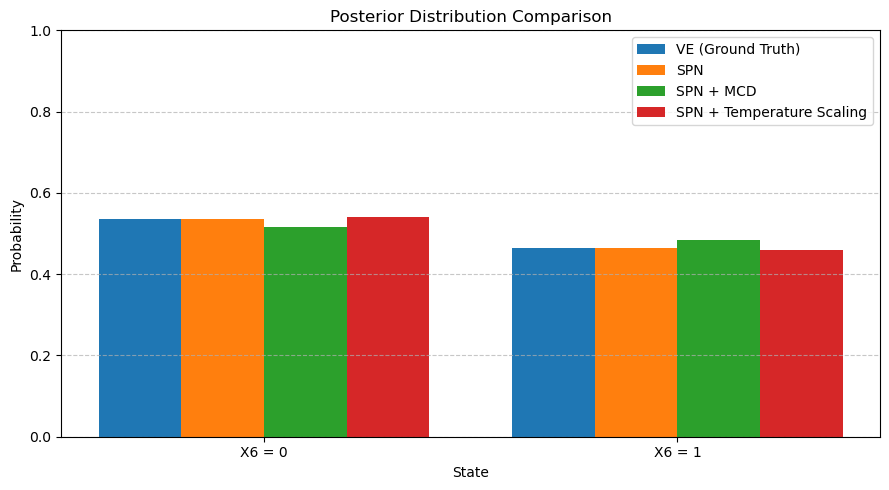

In [34]:
plot_posterior_comparison_with_mcd_and_temp(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    p_temp=p_temp
)


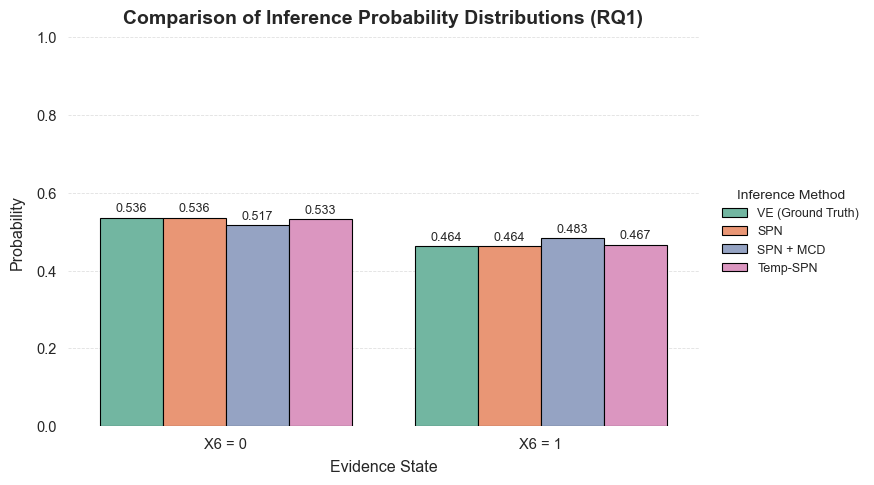

In [35]:
def plot_1(p_ve, p_spn, p_mcd, p_temp):

    # ----------------------------
    # Prepare tidy dataframe
    # ----------------------------
    data = pd.DataFrame({
        "Evidence State": ["X6 = 0", "X6 = 1"] * 4,
        "Probability": np.concatenate([p_ve, p_spn, p_mcd, p_temp]),
        "Method": (
            ["VE (Ground Truth)"] * 2 +
            ["SPN"] * 2 +
            ["SPN + MCD"] * 2 +
            ["Temp-SPN"] * 2
        )
    })

    # ----------------------------
    # Global seaborn style
    # ----------------------------
    sns.set_theme(
        style="whitegrid",
        context="paper",     # cleaner for publications
        font_scale=1.2
    )

    fig, ax = plt.subplots(figsize=(10.5, 5))

    sns.barplot(
        data=data,
        x="Evidence State",
        y="Probability",
        hue="Method",
        palette="Set2",
        edgecolor="black",
        linewidth=0.8,
        ax=ax
    )

    # ----------------------------
    # Annotate bars
    # ----------------------------
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=2,
            fontsize=9
        )

    # ----------------------------
    # Axes styling
    # ----------------------------
    ax.set_ylim(0, 1)
    ax.set_ylabel("Probability", labelpad=8)
    ax.set_xlabel("Evidence State", labelpad=6)
    ax.set_title(
        "Comparison of Inference Probability Distributions (RQ1)",
        fontsize=14,
        weight="bold",
        pad=10
    )

    # Lighten grid
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.grid(axis="x", visible=False)

    # ----------------------------
    # Legend: move outside
    # ----------------------------
    ax.legend(
        title="Inference Method",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        frameon=False,
        fontsize=9,
        title_fontsize=10
    )

    sns.despine(left=True, bottom=True)

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for legend
    #plt.savefig("prob-temp-spn.svg")
    plt.savefig("prob-temp-spn.pdf", format="pdf", bbox_inches="tight")
    plt.show()


plot_1(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    p_temp=upgrade_marg
)

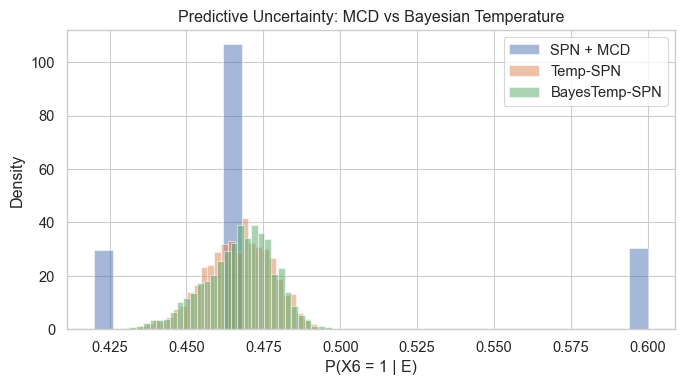

In [36]:
plt.figure(figsize=(7,4))

plt.hist(mcdc_samples, bins=30, density=True, alpha=0.5, label="SPN + MCD")
plt.hist(p1_upgrade_samples, bins=30, density=True, alpha=0.5,label="Temp-SPN")
plt.hist(p1_temp_samples, bins=30, density=True, alpha=0.5,label="BayesTemp-SPN")

plt.xlabel("P(X6 = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty: MCD vs Bayesian Temperature")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\431160628.py:109: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\431160628.py:112: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  plt.savefig('uncertainty_distribution.pdf',
C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\431160628.py:112: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  plt.savefig('uncertainty_distribution.pdf',
C:\Users\admin_mbmaseko\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8326 (\N{SUBSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


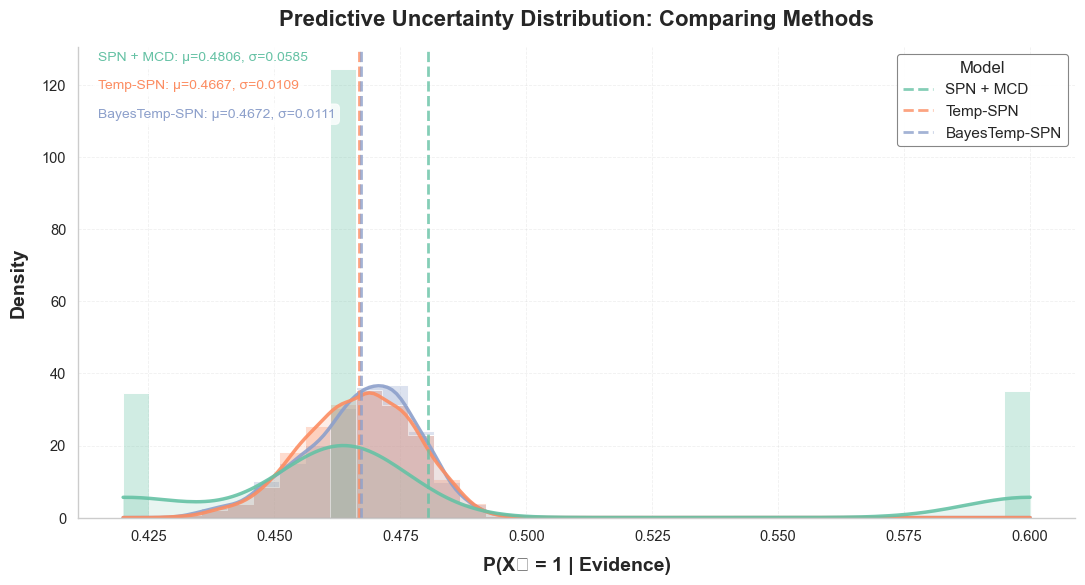

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

# Set style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Create figure
fig, ax = plt.subplots(figsize=(11, 6))

# Prepare data - FIXED: Flatten numpy arrays if they're nested
data_list = []
samples_list = [mcdc_samples, p1_upgrade_samples, p1_temp_samples]
labels_list = ['SPN + MCD', 'Temp-SPN', 'BayesTemp-SPN']

for sample, label in zip(samples_list, labels_list):
    # Flatten the array to ensure 1D
    sample_flat = np.asarray(sample).flatten()
    data_list.extend([{'Model': label, 'Probability': float(val)} 
                      for val in sample_flat])

df = pd.DataFrame(data_list)

# Create beautiful histogram with enhanced KDE
sns.histplot(data=df, 
             x='Probability', 
             hue='Model',
             bins=35,
             kde=True,
             stat='density',
             palette='Set2',
             alpha=0.3,
             edgecolor='white',
             linewidth=0.7,
             element='step',  # Creates cleaner histogram edges
             common_norm=False,  # Each histogram normalized separately
             ax=ax)

# Enhance KDE lines (but only for actual KDE lines, not other lines)
kde_lines = [line for line in ax.lines if 'KDE' in str(line.get_label()) or line.get_linewidth() > 1]
for line in kde_lines:
    line.set_linewidth(2.5)
    line.set_alpha(0.9)

# Add mean markers
for model, color in zip(labels_list, sns.color_palette('Set2', 3)):
    mean_val = df[df['Model'] == model]['Probability'].mean()
    ax.axvline(x=mean_val, color=color, linestyle='--', 
               linewidth=2, alpha=0.8, label=f'{model}')

# Customize plot
ax.set_xlabel('P(X₆ = 1 | Evidence)', 
              fontsize=14, 
              fontweight='semibold',
              labelpad=10)
ax.set_ylabel('Density', 
              fontsize=14, 
              fontweight='semibold',
              labelpad=10)
ax.set_title('Predictive Uncertainty Distribution: Comparing Methods',
             fontsize=16, 
             fontweight='bold',
             pad=15)

# Add fill between distributions for visual comparison (optional)
x_range = np.linspace(df['Probability'].min(), df['Probability'].max(), 200)
for model, color in zip(labels_list, sns.color_palette('Set2', 3)):
    kde = stats.gaussian_kde(df[df['Model'] == model]['Probability'])
    y_kde = kde(x_range)
    ax.fill_between(x_range, y_kde, alpha=0.15, color=color)

# Customize legend
handles, labels = ax.get_legend_handles_labels()
# Filter out duplicate labels
unique_labels = []
unique_handles = []
for h, l in zip(handles, labels):
    if l not in unique_labels:
        unique_labels.append(l)
        unique_handles.append(h)
ax.legend(unique_handles, unique_labels,
          fontsize=11,
          title='Model',
          title_fontsize=12,
          frameon=True,
          framealpha=0.95,
          edgecolor='gray',
          loc='upper right')

# Customize grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6)

# Remove spines
sns.despine()

# Add text annotations for statistics
text_y = 0.97
for model, color in zip(labels_list, sns.color_palette('Set2', 3)):
    subset = df[df['Model'] == model]['Probability']
    text = f"{model}: μ={subset.mean():.4f}, σ={subset.std():.4f}"
    ax.text(0.02, text_y, text, transform=ax.transAxes,
            fontsize=10, color=color, fontweight='medium',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    text_y -= 0.06

plt.tight_layout()

# Save
plt.savefig('uncertainty_distribution.pdf', 
            format='pdf', 
            bbox_inches='tight', 
            dpi=300)
plt.show()

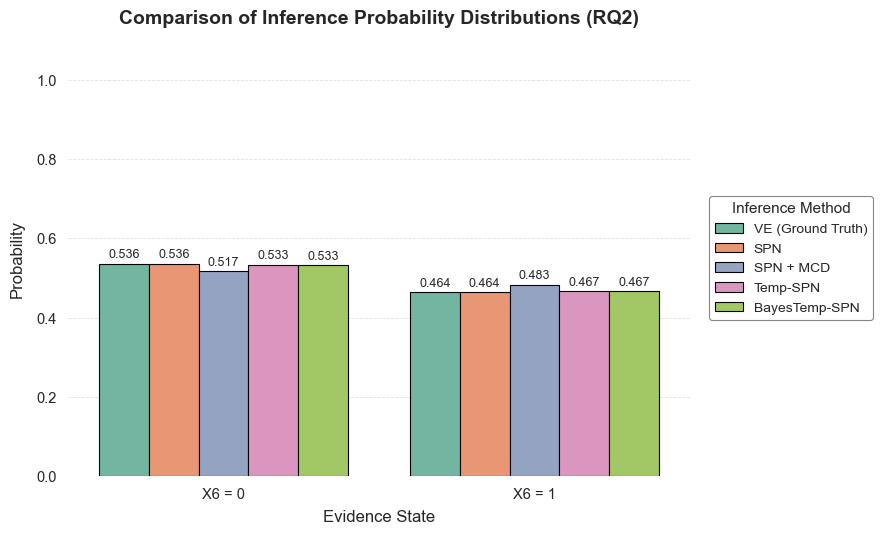

In [38]:
def plot_2(p_ve, p_spn, p_mcd, p_temp, p_upgrade):
    """
    p_ve      : [P(X=0), P(X=1)] from Variable Elimination (ground truth)
    p_spn     : deterministic SPN posterior
    p_mcd     : Monte Carlo Dropout posterior mean
    p_temp    : Temperature-scaled SPN posterior
    p_upgrade : BayesTemp-SPN posterior (new addition)
    """

    # ----------------------------
    # Prepare tidy dataframe - NOW WITH 5 METHODS
    # ----------------------------
    data = pd.DataFrame({
        "Evidence State": ["X6 = 0", "X6 = 1"] * 5,  # Changed from 4 to 5
        "Probability": np.concatenate([p_ve, p_spn, p_mcd, p_temp, p_upgrade]),
        "Method": (
            ["VE (Ground Truth)"] * 2 +
            ["SPN"] * 2 +
            ["SPN + MCD"] * 2 +
            ["Temp-SPN"] * 2 +
            ["BayesTemp-SPN"] * 2  # New method added
        )
    })

    # ----------------------------
    # Global seaborn style
    # ----------------------------
    sns.set_theme(
        style="whitegrid",
        context="paper",     # cleaner for publications
        font_scale=1.2
    )

    # Slightly wider figure to accommodate more bars
    fig, ax = plt.subplots(figsize=(11, 5.5))

    # Use a colorblind-friendly palette with 5 distinct colors
    palette = sns.color_palette("Set2", 5)  # Or "husl", "tab10", "colorblind"
    
    sns.barplot(
        data=data,
        x="Evidence State",
        y="Probability",
        hue="Method",
        palette=palette,
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
        dodge=True  # Ensure proper grouping
    )

    # ----------------------------
    # Annotate bars
    # ----------------------------
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=2,
            fontsize=9
        )

    # ----------------------------
    # Axes styling
    # ----------------------------
    ax.set_ylim(0, 1.1)  # Slightly higher for annotations
    ax.set_ylabel("Probability", labelpad=8, fontsize=12)
    ax.set_xlabel("Evidence State", labelpad=6, fontsize=12)
    ax.set_title(
        "Comparison of Inference Probability Distributions (RQ2)",
        fontsize=14,
        weight="bold",
        pad=12
    )

    # Lighten grid
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.grid(axis="x", visible=False)

    # ----------------------------
    # Legend: move outside with more space
    # ----------------------------
    ax.legend(
        title="Inference Method",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        frameon=True,
        framealpha=0.95,
        edgecolor='gray',
        fontsize=10,
        title_fontsize=11
    )

    sns.despine(left=True, bottom=True)

    # Adjust layout to accommodate legend
    plt.tight_layout(rect=[0, 0, 0.82, 1])  # More space for legend
    
    # Save both SVG and PDF
    plt.savefig("prob-temp-spn-bayes.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.savefig("prob-temp-spn-bayes.svg", format="svg", bbox_inches="tight")
    plt.show()


# Call the function with all 5 arguments
plot_2(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    p_temp=upgrade_marg,  # Make sure this is your temperature-scaled SPN
    p_upgrade= p_temp_marg # Your BayesTemp-SPN results
)

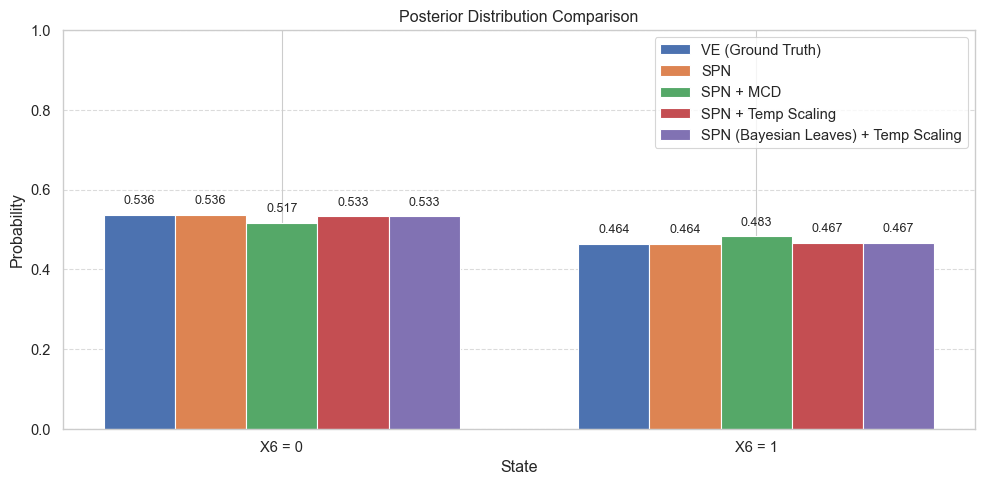

In [39]:
def plot1(p_ve, p_spn, p_mcd, p_temp, p_temp_marg):
    """
    p_ve       : [P(X=0), P(X=1)] from Variable Elimination (ground truth)
    p_spn      : deterministic SPN posterior
    p_mcd      : Monte Carlo Dropout posterior mean
    p_temp     : Temperature-scaled SPN posterior
    p_temp_marg: Marginal-temperature-scaled SPN posterior
    """

    labels = ["X6 = 0", "X6 = 1"]
    x = np.arange(len(labels))
    width = 0.15  # narrower to fit 5 bars

    plt.figure(figsize=(10, 5))

    bars_ve   = plt.bar(x - 2*width, p_ve,        width, label="VE (Ground Truth)")
    bars_spn  = plt.bar(x - width,   p_spn,       width, label="SPN")
    bars_mcd  = plt.bar(x,           p_mcd,       width, label="SPN + MCD")
    bars_temp = plt.bar(x + width,   p_temp,      width, label="SPN + Temp Scaling")
    bars_marg = plt.bar(x + 2*width, p_temp_marg, width, label="SPN (Bayesian Leaves) + Temp Scaling")

    # ---- Annotate bars with values ----
    def annotate_bars(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    for bars in [bars_ve, bars_spn, bars_mcd, bars_temp, bars_marg]:
        annotate_bars(bars)

    plt.ylabel("Probability")
    plt.xlabel("State")
    plt.title("Posterior Distribution Comparison")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


plot1(
    p_ve=p_ve,
    p_spn=p_spn,
    p_mcd=p_mcd,
    p_temp=upgrade_marg,
    p_temp_marg=p_temp_marg
)

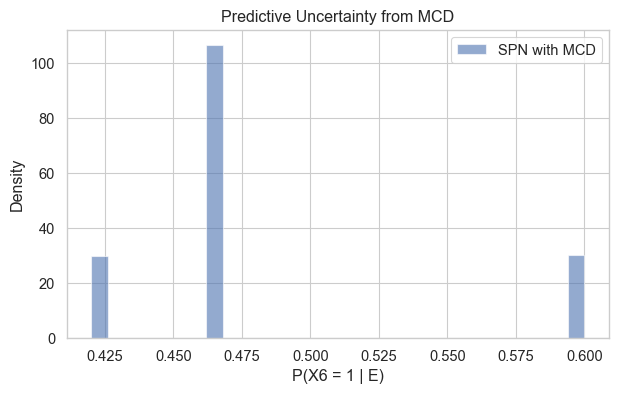

In [40]:
plt.figure(figsize=(7,4))

plt.hist(
    mcdc_samples,
    bins=30,
    density=True,
    alpha=0.6,
    label="SPN with MCD"
)

plt.xlabel("P(X6 = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty from MCD")
plt.legend()
plt.show()


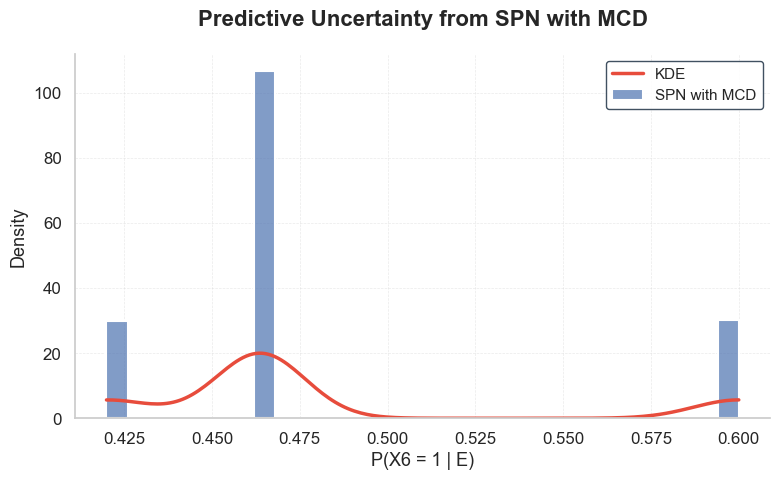

In [41]:
# Set style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure with appropriate size
plt.figure(figsize=(8, 5))

# Create the histogram using seaborn
ax = sns.histplot(
    data=mcdc_samples,
    bins=30,
    kde=True,  # Adds kernel density estimation line
    stat="density",
    color="#3498db",  # Attractive blue color
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7,
    label="SPN with MCD"
)

# Customize the KDE line for better visibility
if ax.lines:  # Check if KDE line exists
    ax.lines[0].set_color('#e74c3c')  # Red color for KDE
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_linestyle('-')
    ax.lines[0].set_label("KDE")

# Add styling elements
plt.xlabel("P(X6 = 1 | E)", fontsize=13, fontweight='medium')
plt.ylabel("Density", fontsize=13, fontweight='medium')
plt.title("Predictive Uncertainty from SPN with MCD", 
          fontsize=16, 
          fontweight='bold',
          pad=20)

# Customize legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='#2c3e50',
    loc='best'
)

# Add grid for better readability (seaborn already provides whitegrid)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

# Remove top and right spines for cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout
plt.tight_layout()

#plt.savefig("mcd_uncertainty.svg")
plt.savefig("mcd_uncertainty.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

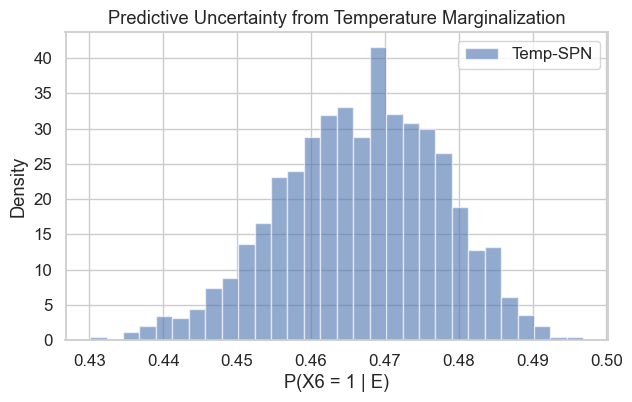

In [42]:
plt.figure(figsize=(7,4))

plt.hist(
    p1_upgrade_samples,
    bins=30,
    density=True,
    alpha=0.6,
    label="Temp-SPN"
)

plt.xlabel("P(X6 = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty from Temperature Marginalization")
plt.legend()
plt.show()


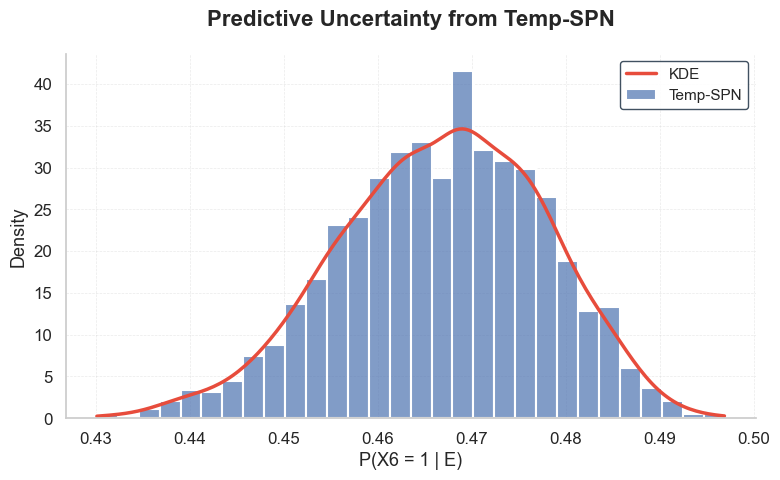

In [43]:
# Set style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure with appropriate size
plt.figure(figsize=(8, 5))

# Create the histogram using seaborn
ax = sns.histplot(
    data=p1_upgrade_samples,
    bins=30,
    kde=True,  # Adds kernel density estimation line
    stat="density",
    color="#3498db",  # Attractive blue color
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7,
    label="Temp-SPN"
)

# Customize the KDE line for better visibility
if ax.lines:  # Check if KDE line exists
    ax.lines[0].set_color('#e74c3c')  # Red color for KDE
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_linestyle('-')
    ax.lines[0].set_label("KDE")

# Add styling elements
plt.xlabel("P(X6 = 1 | E)", fontsize=13, fontweight='medium')
plt.ylabel("Density", fontsize=13, fontweight='medium')
plt.title("Predictive Uncertainty from Temp-SPN", 
          fontsize=16, 
          fontweight='bold',
          pad=20)

# Customize legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='#2c3e50',
    loc='best'
)

# Add grid for better readability (seaborn already provides whitegrid)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

# Remove top and right spines for cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout
plt.tight_layout()

#plt.savefig("tempspn_uncertainty.svg")
plt.savefig("tempspn_uncertainty.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

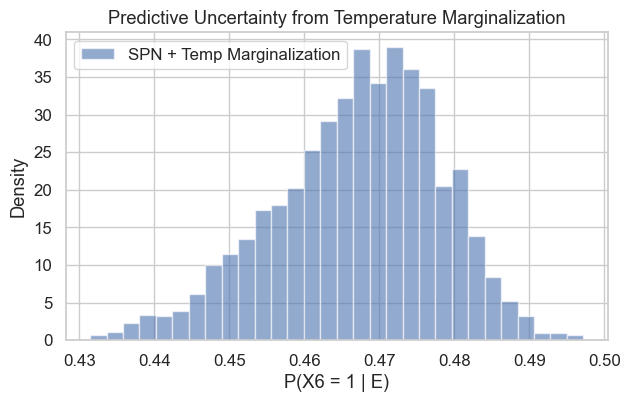

In [44]:
plt.figure(figsize=(7,4))

plt.hist(
    p1_temp_samples,
    bins=30,
    density=True,
    alpha=0.6,
    label="SPN + Temp Marginalization"
)

plt.xlabel("P(X6 = 1 | E)")
plt.ylabel("Density")
plt.title("Predictive Uncertainty from Temperature Marginalization")
plt.legend()
plt.show()


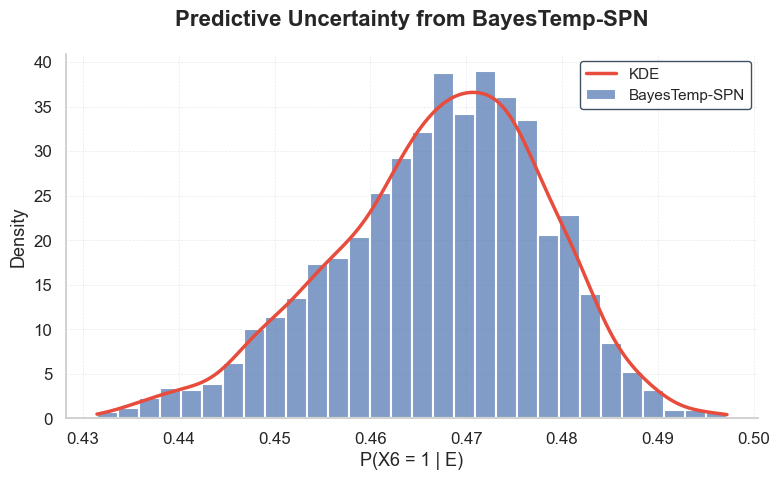

In [45]:
# Set style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create figure with appropriate size
plt.figure(figsize=(8, 5))

# Create the histogram using seaborn
ax = sns.histplot(
    data=p1_temp_samples,
    bins=30,
    kde=True,  # Adds kernel density estimation line
    stat="density",
    color="#3498db",  # Attractive blue color
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7,
    label="BayesTemp-SPN"
)

# Customize the KDE line for better visibility
if ax.lines:  # Check if KDE line exists
    ax.lines[0].set_color('#e74c3c')  # Red color for KDE
    ax.lines[0].set_linewidth(2.5)
    ax.lines[0].set_linestyle('-')
    ax.lines[0].set_label("KDE")

# Add styling elements
plt.xlabel("P(X6 = 1 | E)", fontsize=13, fontweight='medium')
plt.ylabel("Density", fontsize=13, fontweight='medium')
plt.title("Predictive Uncertainty from BayesTemp-SPN", 
          fontsize=16, 
          fontweight='bold',
          pad=20)

# Customize legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='#2c3e50',
    loc='best'
)

# Add grid for better readability (seaborn already provides whitegrid)
plt.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

# Remove top and right spines for cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout
plt.tight_layout()

#plt.savefig("tempspn_uncertainty.svg")
plt.savefig("bayestempspn_uncertainty.pdf", format="pdf", bbox_inches="tight")
# Show plot
plt.show()

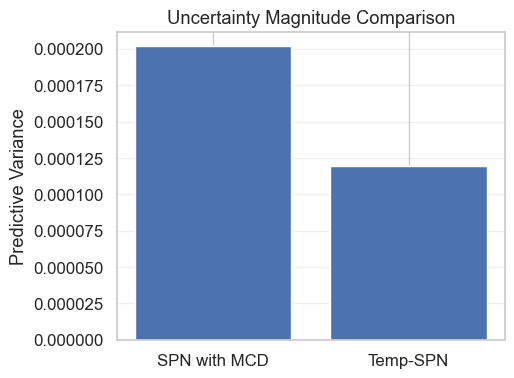

In [46]:
plt.figure(figsize=(5,4))
plt.bar(
    ["SPN with MCD", "Temp-SPN"],
    [np.var(mcd_samples), p1_upgrade_var]
)
plt.ylabel("Predictive Variance")
plt.title("Uncertainty Magnitude Comparison")
plt.grid(axis="y", alpha=0.3)
plt.savefig("uncertainty maginitude.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\2416231701.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, fontsize=13, fontweight='medium')


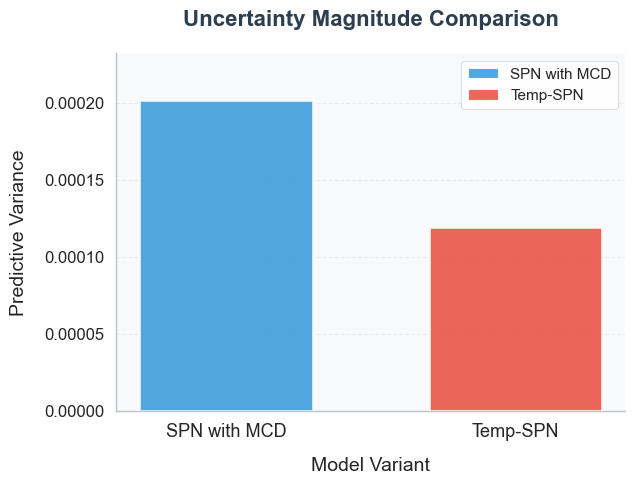

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Set academic style - clean and professional
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)  # Use "paper" context for academic plots

# Create figure with appropriate dimensions for thesis
fig, ax = plt.subplots(figsize=(6.5, 5))  # Slightly larger for better readability

# Prepare data
categories = ["SPN with MCD", "Temp-SPN"]
variances = [np.var(mcd_samples), p1_upgrade_var]

# Choose professional color palette (colorblind-friendly)
colors = ['#3498db', '#e74c3c']  # Blue and red
# Or use a sequential palette: colors = sns.color_palette("Blues", 2)

# Create bar plot with seaborn (even though it's simple, we'll style it professionally)
bars = ax.bar(
    categories,
    variances,
    color=colors,
    edgecolor='white',
    linewidth=2,
    width=0.6,
    alpha=0.85,
    zorder=3
)

# Customize y-axis
ax.set_ylabel('Predictive Variance', 
              fontsize=14, 
              fontweight='medium',
              labelpad=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.set_ylim(0, max(variances) * 1.15)  # Add 15% padding on top

# Customize x-axis
ax.set_xlabel('Model Variant', 
              fontsize=14, 
              fontweight='medium',
              labelpad=12)
ax.set_xticklabels(categories, fontsize=13, fontweight='medium')

# Set title with proper academic formatting
ax.set_title('Uncertainty Magnitude Comparison', 
             fontsize=16, 
             fontweight='bold',
             pad=20,
             color='#2c3e50')

# Customize grid
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.grid(False, axis='x')  # Remove x-grid for cleaner look

# Remove top and right spines
sns.despine(left=False, bottom=False, top=True, right=True)

# Add a subtle background color to distinguish from white page
ax.set_facecolor('#f8f9fa')

# Optionally add a horizontal line at a reference point (e.g., baseline)
# ax.axhline(y=baseline_var, color='gray', linestyle=':', alpha=0.7, linewidth=1.5)

# Create custom legend (optional, but nice for color explanation)
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='white', alpha=0.85, label='SPN with MCD'),
    Patch(facecolor=colors[1], edgecolor='white', alpha=0.85, label='Temp-SPN')
]
ax.legend(handles=legend_elements, 
          loc='upper right',
          fontsize=11,
          frameon=True,
          framealpha=0.95,
          edgecolor='#ddd')

# Add a subtle border around the plot for PDF export
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1)

# Ensure tight layout
plt.tight_layout()

# Save for thesis (high quality PDF)
plt.savefig("uncertainty_magnitude.pdf", 
            format="pdf", 
            bbox_inches="tight",
            dpi=300,
            facecolor='white',
            edgecolor='none')

plt.show()

C:\Users\admin_mbmaseko\AppData\Local\Temp\ipykernel_4860\2130138625.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, fontsize=13, fontweight='medium')


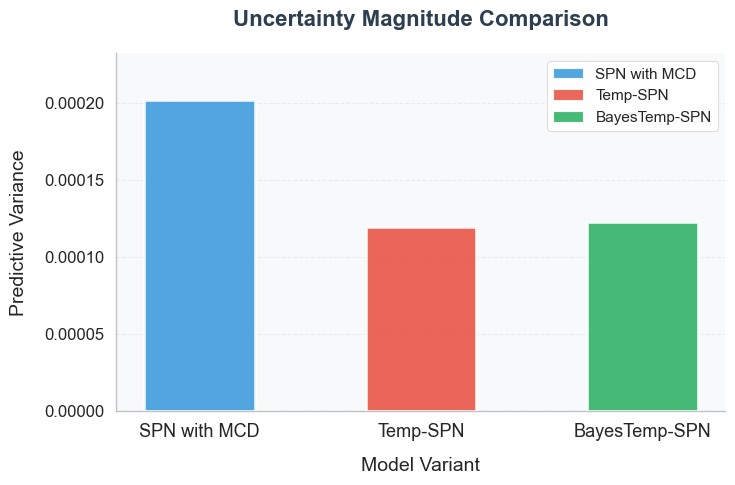

In [48]:
# Set academic style - clean and professional
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)  # Use "paper" context for academic plots

# Create figure with appropriate dimensions for thesis
fig, ax = plt.subplots(figsize=(7.5, 5))  # Slightly wider to accommodate 3 bars

# Prepare data - NOW WITH 3 CATEGORIES
categories = ["SPN with MCD", "Temp-SPN", "BayesTemp-SPN"]
variances = [np.var(mcd_samples), np.var(p1_upgrade_samples), np.var(p1_temp_samples)]  # Add BayesTemp-SPN variance

# Choose professional color palette (colorblind-friendly)
# Maintain original colors for first two, add green for BayesTemp-SPN
colors = ['#3498db', '#e74c3c', '#27ae60']  # Blue, Red, Green

# Create bar plot with seaborn
bars = ax.bar(
    categories,
    variances,
    color=colors,
    edgecolor='white',
    linewidth=2,
    width=0.5,  # Slightly narrower width for 3 bars
    alpha=0.85,
    zorder=3
)

# Customize y-axis
ax.set_ylabel('Predictive Variance', 
              fontsize=14, 
              fontweight='medium',
              labelpad=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.set_ylim(0, max(variances) * 1.15)  # Add 15% padding on top

# Customize x-axis
ax.set_xlabel('Model Variant', 
              fontsize=14, 
              fontweight='medium',
              labelpad=12)
ax.set_xticklabels(categories, fontsize=13, fontweight='medium')

# Set title with proper academic formatting
ax.set_title('Uncertainty Magnitude Comparison', 
             fontsize=16, 
             fontweight='bold',
             pad=20,
             color='#2c3e50')

# Customize grid
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.grid(False, axis='x')  # Remove x-grid for cleaner look

# Remove top and right spines
sns.despine(left=False, bottom=False, top=True, right=True)

# Add a subtle background color to distinguish from white page
ax.set_facecolor('#f8f9fa')

# Optionally add a horizontal line at a reference point (e.g., baseline)
# ax.axhline(y=baseline_var, color='gray', linestyle=':', alpha=0.7, linewidth=1.5)

# Create custom legend (updated for 3 methods)
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='white', alpha=0.85, label='SPN with MCD'),
    Patch(facecolor=colors[1], edgecolor='white', alpha=0.85, label='Temp-SPN'),
    Patch(facecolor=colors[2], edgecolor='white', alpha=0.85, label='BayesTemp-SPN')
]
ax.legend(handles=legend_elements, 
          loc='upper right',
          fontsize=11,
          frameon=True,
          framealpha=0.95,
          edgecolor='#ddd')

# Add a subtle border around the plot for PDF export
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1)

# Ensure tight layout
plt.tight_layout()

# Save for thesis (high quality PDF)
plt.savefig("uncertainty_magnitude_comparisonRQ2.pdf", 
            format="pdf", 
            bbox_inches="tight",
            dpi=300,
            facecolor='white',
            edgecolor='none')

plt.show()

In [49]:
#Table
def posterior_summary_table(
    p_ve,
    p_spn,
    p_mcd,
    upgrade_marg
):
    """
    Creates a summary table of posterior probabilities.

    Each input is expected to be:
        [P(X6=0 | E), P(X6=1 | E)]
    """

    data = {
        "Model": [
            "VE (Ground Truth)",
            "SPN",
            "SPN + MCD",
            "Temp-SPN"
        ],
        "P(X6 = 0 | E)": [
            p_ve[0],
            p_spn[0],
            p_mcd[0],
            upgrade_marg[0]
        ],
        "P(X6 = 1 | E)": [
            p_ve[1],
            p_spn[1],
            p_mcd[1],
            upgrade_marg[1]
        ]
    }

    df = pd.DataFrame(data)

    # Optional formatting for readability
    df["P(X6 = 0 | E)"] = df["P(X6 = 0 | E)"].astype(float)
    df["P(X6 = 1 | E)"] = df["P(X6 = 1 | E)"].astype(float)

    return df
summary_df = posterior_summary_table(p_ve=p_ve, p_spn=p_spn, p_mcd=p_mcd, upgrade_marg=upgrade_marg)
print(summary_df)


               Model  P(X6 = 0 | E)  P(X6 = 1 | E)
0  VE (Ground Truth)       0.536268       0.463732
1                SPN       0.536268       0.463732
2          SPN + MCD       0.517155       0.482845
3           Temp-SPN       0.533262       0.466738


In [50]:
#Table
def posterior_summary_table(
    p_ve,
    p_spn,
    p_mcd,
    p_temp_marg,
    upgrade_marg
):
    """
    Creates a summary table of posterior probabilities.

    Each input is expected to be:
        [P(X6=0 | E), P(X6=1 | E)]
    """

    data = {
        "Model": [
            "VE (Ground Truth)",
            "SPN",
            "SPN + MCD",
            "Temp-SPN",
            "BayesTemp-SPN"
        ],
        "P(X6 = 0 | E)": [
            p_ve[0],
            p_spn[0],
            p_mcd[0],
            upgrade_marg[0],
            p_temp_marg[0]
            
        ],
        "P(X6 = 1 | E)": [
            p_ve[1],
            p_spn[1],
            p_mcd[1],
            upgrade_marg[1],
            p_temp_marg[1]
            
        ]
    }

    df = pd.DataFrame(data)

    # Optional formatting for readability
    df["P(X6 = 0 | E)"] = df["P(X6 = 0 | E)"].astype(float)
    df["P(X6 = 1 | E)"] = df["P(X6 = 1 | E)"].astype(float)

    return df
summary_df = posterior_summary_table(p_ve=p_ve, p_spn=p_spn, p_mcd=p_mcd, p_temp_marg=p_temp_marg, upgrade_marg=upgrade_marg)
print(summary_df)


               Model  P(X6 = 0 | E)  P(X6 = 1 | E)
0  VE (Ground Truth)       0.536268       0.463732
1                SPN       0.536268       0.463732
2          SPN + MCD       0.517155       0.482845
3           Temp-SPN       0.533262       0.466738
4      BayesTemp-SPN       0.532848       0.467152


Error Calculation

In [51]:
def posterior_mae(p_model, p_ve):
    """
    Mean Absolute Error between two Bernoulli posteriors
    """
    p_model = np.asarray(p_model)
    p_ve = np.asarray(p_ve)
    return np.mean(np.abs(p_model - p_ve))

In [52]:
mcd_mae = posterior_mae(p_mcd, p_ve)
temp_marg_mae = posterior_mae(p_temp_marg, p_ve)
upgrade_mae = posterior_mae(upgrade_marg, p_ve)

print(f"SPN + MCD:")
print(f"  MAE = {mcd_mae:.6f}")

print(f"\nSPN + Temperature Marginalization:")
print(f"  MAE = {upgrade_mae:.6f}")

print(f"\nBaySPN + Temperature Marginalization:")
print(f"  MAE = {temp_marg_mae:.6f}")

SPN + MCD:
  MAE = 0.019113

SPN + Temperature Marginalization:
  MAE = 0.003005

BaySPN + Temperature Marginalization:
  MAE = 0.003419


In [53]:
def samplewise_mae(p1_samples, p_ve):
    """
    Compute MAE per Monte Carlo sample for Bernoulli posterior

    p1_samples : array of P(X6=1 | E) samples
    p_ve       : [P(X6=0), P(X6=1)] from VE
    """
    p0_ve, p1_ve = p_ve

    mae = []
    for p1 in p1_samples:
        p0 = 1.0 - p1
        mae.append(
            0.5 * (abs(p0 - p0_ve) + abs(p1 - p1_ve))
        )

    return np.array(mae)

mae_mcd = samplewise_mae(mcdc_samples, p_ve)
mae_temp = samplewise_mae(p1_temp_samples, p_ve)
mae_upgrade = samplewise_mae(p1_upgrade_samples, p_ve)

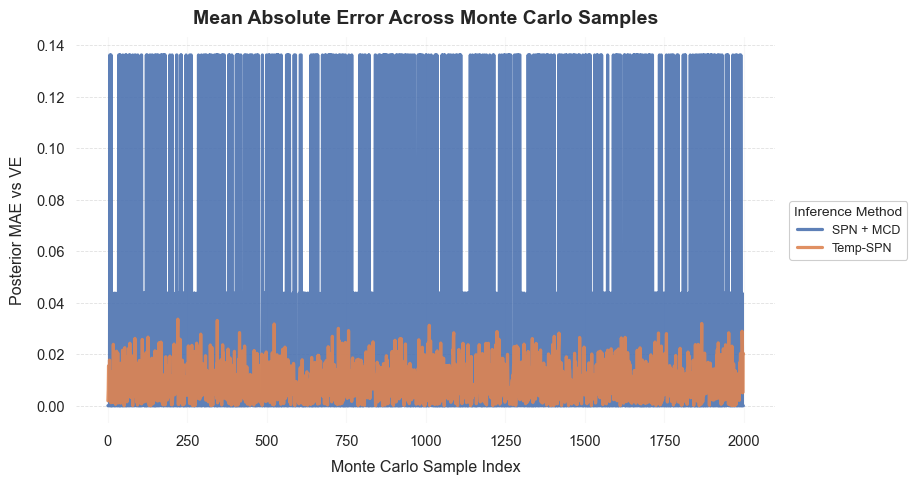

In [54]:
def plot_mae_seaborn(mae_mcd, mae_upgrade):

    # ----------------------------
    # Prepare tidy dataframe
    # ----------------------------
    # ----------------------------
    # Prepare tidy dataframe (With Flattening)
    # ----------------------------
    df = pd.concat([
        pd.DataFrame({
            "Monte Carlo Sample Index": np.arange(len(mae_mcd)),
            "MAE": np.array(mae_mcd).flatten(),  # Force to 1D
            "Method": "SPN + MCD"
        }),
        pd.DataFrame({
            "Monte Carlo Sample Index": np.arange(len(mae_upgrade)),
            "MAE": np.array(mae_upgrade).flatten(),  # Force to 1D
            "Method": "Temp-SPN"
        })
    ], ignore_index=True)
    # ----------------------------
    # Seaborn theme (paper-grade)
    # ----------------------------
    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.2
    )

    fig, ax = plt.subplots(figsize=(11, 5))

    sns.lineplot(
        data=df,
        x="Monte Carlo Sample Index",
        y="MAE",
        hue="Method",
        palette={
            "SPN + MCD": "#4C72B0",
            "Temp-SPN": "#DD8452"
        },
        linewidth=2.3,
        alpha=0.9,
        ax=ax
    )

    # ----------------------------
    # Axes styling
    # ----------------------------
    ax.set_xlabel("Monte Carlo Sample Index", labelpad=8)
    ax.set_ylabel("Posterior MAE vs VE", labelpad=8)

    ax.set_title(
        "Mean Absolute Error Across Monte Carlo Samples",
        fontsize=14,
        weight="bold",
        pad=10
    )

    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.grid(axis="x", alpha=0.15)

    sns.despine(left=True, bottom=True)

    # ----------------------------
    # LEGEND: outside, readable, stable
    # ----------------------------
    legend = ax.legend(
        title="Inference Method",
        bbox_to_anchor=(1.02, 0.5),   # outside to the right
        loc="center left",
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        borderaxespad=0.0
    )

    # Make legend frame subtle but readable
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor("0.8")

    # Leave space on the right for legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    plt.savefig("mae_vs_ve_seaborn.svg")
    plt.show()

plot_mae_seaborn(mae_mcd=mae_mcd, mae_upgrade=mae_upgrade)

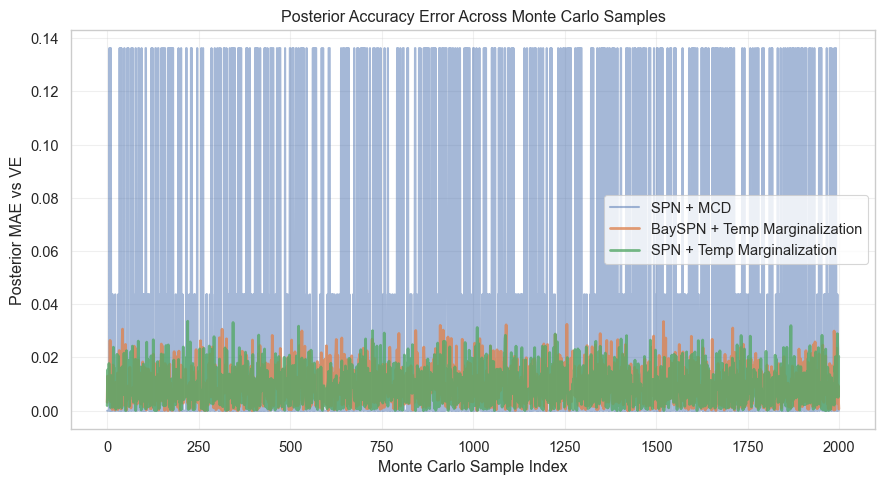

In [55]:
plt.figure(figsize=(9, 5))

plt.plot(
    mae_mcd,
    alpha=0.5,
    label="SPN + MCD",
    linewidth=1.5
)

plt.plot(
    mae_temp,
    alpha=0.8,
    label="BaySPN + Temp Marginalization",
    linewidth=2
)

plt.plot(
    mae_upgrade,
    alpha=0.8,
    label="SPN + Temp Marginalization",
    linewidth=2
)

plt.ylabel("Posterior MAE vs VE")
plt.xlabel("Monte Carlo Sample Index")
plt.title("Posterior Accuracy Error Across Monte Carlo Samples")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


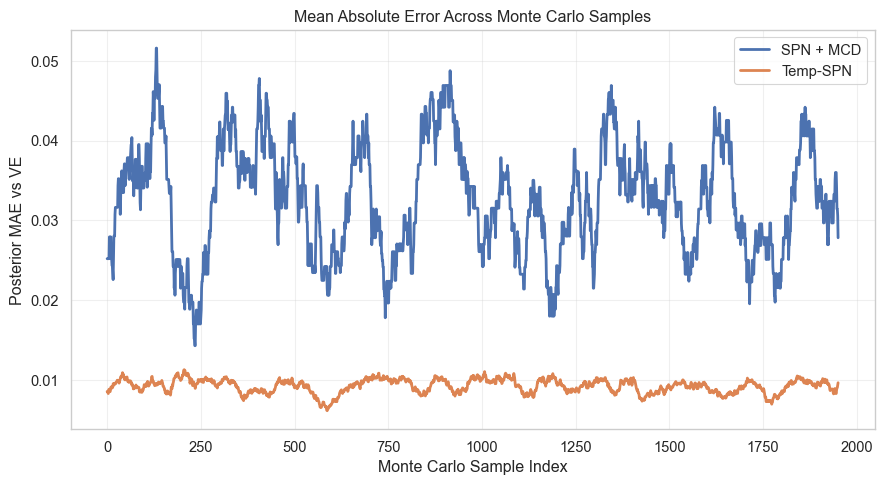

In [56]:
# Ensure 1D
mae_mcd = np.asarray(mae_mcd).reshape(-1)
mae_temp = np.asarray(mae_temp).reshape(-1)
mae_upgrade = np.asarray(mae_upgrade).reshape(-1)

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(w) / w, mode="valid")

w = 50  # smoothing window

plt.figure(figsize=(9, 5))

plt.plot(
    moving_average(mae_mcd, w),
    label="SPN + MCD",
    linewidth=2
)

plt.plot(
    moving_average(mae_upgrade, w),
    label="Temp-SPN",
    linewidth=2
)

plt.ylabel("Posterior MAE vs VE")
plt.xlabel("Monte Carlo Sample Index")
plt.title("Mean Absolute Error Across Monte Carlo Samples")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("mae_vs_ve_seaborn_1.svg")
plt.savefig("mae_vs_ve_expr_1.pdf", format="pdf", bbox_inches="tight")
plt.show()


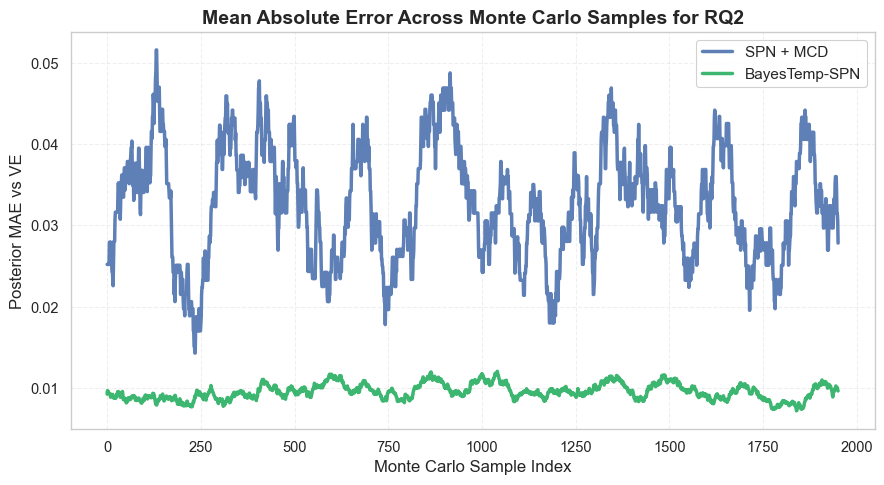

In [57]:
# Ensure 1D
mae_mcd = np.asarray(mae_mcd).reshape(-1)
mae_temp = np.asarray(mae_temp).reshape(-1)
mae_upgrade = np.asarray(mae_upgrade).reshape(-1)

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(w) / w, mode="valid")

w = 50  # smoothing window

plt.figure(figsize=(9, 5))

# Plot SPN + MCD with blue color
plt.plot(
    moving_average(mae_mcd, w),
    label="SPN + MCD",
    linewidth=2.5,
    alpha=0.9
)

# Plot BayesTemp-SPN with greenish color
plt.plot(
    moving_average(mae_temp, w),  # Assuming mae_upgrade is BayesTemp-SPN
    label="BayesTemp-SPN",
    linewidth=2.5,
    color='#27ae60',  # Green color
    alpha=0.9
)

plt.ylabel("Posterior MAE vs VE", fontsize=12)
plt.xlabel("Monte Carlo Sample Index", fontsize=12)
plt.title("Mean Absolute Error Across Monte Carlo Samples for RQ2", fontsize=14, fontweight='bold')
plt.legend(fontsize=11, frameon=True, framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("mae_vs_ve_expr_2.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

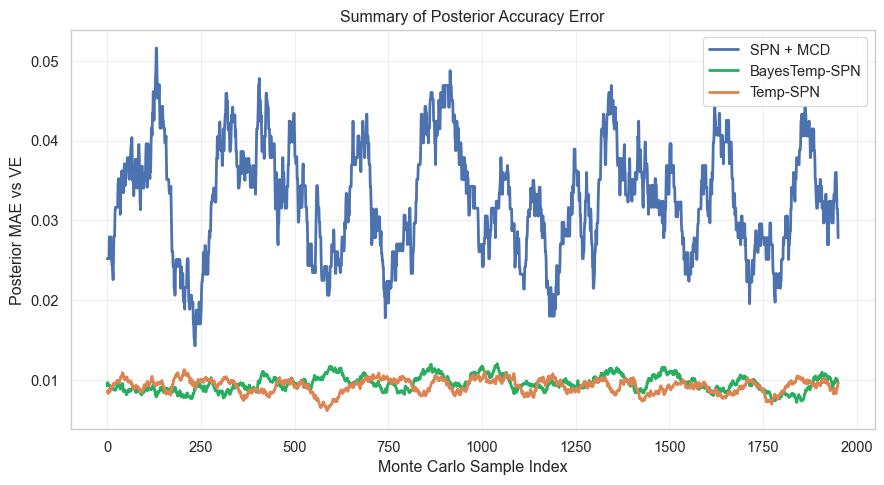

In [58]:
# Ensure 1D
mae_mcd = np.asarray(mae_mcd).reshape(-1)
mae_temp = np.asarray(mae_temp).reshape(-1)
mae_upgrade = np.asarray(mae_upgrade).reshape(-1)

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(w) / w, mode="valid")

w = 50  # smoothing window

plt.figure(figsize=(9, 5))

plt.plot(
    moving_average(mae_mcd, w),
    label="SPN + MCD",
    linewidth=2
)

plt.plot(
    moving_average(mae_temp, w),
    label="BayesTemp-SPN",
    linewidth=2,
    color='#27ae60'  # Green color
)

plt.plot(
    moving_average(mae_upgrade, w),
    label="Temp-SPN",
    linewidth=2
)

plt.ylabel("Posterior MAE vs VE")
plt.xlabel("Monte Carlo Sample Index")
plt.title("Summary of Posterior Accuracy Error")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mae_vs_ve_summary.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()
